# Mercado justo: Análisis y predicción de precios en productos avícolas

**Proyecto elaborado por:**

> *García Pineda Nayeli*

> *Muñoz López Andrea*

> *Ortega Cortés Geovani*

> *Sillero Colin Alejandra Yazmín*

In [1]:
%pip install folium


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pyspark.sql import SparkSession
import pandas as pd
import requests

spark = SparkSession.builder \
    .appName("MercadoJustoAvicola") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

url_pollo  = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/e13f191a95f6fdb74f8b95286e5fb88220cb3350/BASE%20DE%20DATOS.csv"
url_export = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/main/Historico%20de%20exportaciones-productos%20avicolas.csv"

pd_pollo  = pd.read_csv(url_pollo,  encoding='latin1')
pd_export = pd.read_csv(url_export, encoding='latin1')

df_pollo_spark  = spark.createDataFrame(pd_pollo)
df_export_spark = spark.createDataFrame(pd_export)

df_pollo_spark.printSchema()

root
 |-- ;;;;;;;;;;;;: string (nullable = true)



## Librerias requeridas:

## Ruta de datos:

In [3]:
import math
import folium
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from io import BytesIO, StringIO
from datetime import datetime, timedelta
from scipy.stats import norm
from folium.plugins import MarkerCluster
from IPython.display import display, clear_output
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score

# URLs globales del repositorio
url_pollo  = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/e13f191a95f6fdb74f8b95286e5fb88220cb3350/BASE%20DE%20DATOS.csv"
url_export = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/main/Historico%20de%20exportaciones-productos%20avicolas.csv"
url_excel  = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/main/Historico%20de%20precios-productos%20avicolas.xlsx"

response_csv = requests.get(url_pollo)
df = pd.read_csv(StringIO(response_csv.text), encoding='latin1')

response_export = requests.get(url_export)
df_export = pd.read_csv(StringIO(response_export.content.decode('latin1')), encoding='latin1')

## Modelado y censado de información

### Mapeado y relación de distribución



> La siguiente sección se sustenta bajo los conocimientos de de la UCA de Mineria de Datos





In [4]:
# Ubicaciones de granjas avicolas en México
ubicaciones = [
    {"nombre": "La Paz", "lat": 24.1426, "lon": -110.3128},
    {"nombre": "CDMX - Becerra", "lat": 19.3926, "lon": -99.1966},
    {"nombre": "CDMX - Nuevo San Juan", "lat": 19.3710, "lon": -99.0920},
    {"nombre": "CDMX - Rayón", "lat": 19.4363, "lon": -99.1235},
    {"nombre": "CDMX - San Juan", "lat": 19.3575, "lon": -99.0580},
    {"nombre": "Nay - Centros de Distribución de Nayarit", "lat": 21.5059, "lon": -104.8950},
    {"nombre": "Qro - Centros de distribución de Querétaro", "lat": 20.5888, "lon": -100.3899},
    {"nombre": "Zac - Mercado de Abasto de Zacatecas", "lat": 20.5888, "lon": -100.3899},

    #Ubicaciones pollo entero

    {"nombre": "Tepic", "lat": 21.5095, "lon": -104.8950},
    {"nombre": "Querétaro", "lat": 20.5888, "lon": -100.3899},
    {"nombre": "Zacatecas", "lat": 22.7709, "lon": -102.5832},
    {"nombre": "La Paz - (Diversos establecimientos)", "lat": 24.1426, "lon": -110.3128},
    {"nombre": "Ciudad de México (Centro de distribución Becerra)", "lat": 19.3926, "lon": -99.1966},
    {"nombre": "Ciudad de México (Centro de distribución Nuevo San Juan)", "lat": 19.3710, "lon":-99.0920},
    {"nombre": "Ciudad de México (Centro de distribución Rayón)", "lat": 19.4363, "lon": -99.1235},

    #Ubicaciones de más granjas

    {"nombre": "Avícola Llano Grande (Amecameca)", "lat": 19.128, "lon": -98.766},
    {"nombre": "Avícola San Andrés (Zumpango)", "lat": 19.796, "lon": -99.101},
    {"nombre": "Granjas Avícolas Rocer", "lat": 19.796, "lon": -99.101},
    {"nombre": "Granja El Gran Pavo (Chalco)", "lat": 19.264, "lon": -98.897},
    {"nombre": "Comercializadora de Productos Avícolas Mex (Chimalhuacán)", "lat": 19.408, "lon": -98.904},
    {"nombre": "Avícola Sta. Ana de Atizapán", "lat": 19.561, "lon": -99.267},
    {"nombre": "Avícola Cuera (Valle de Chalco)", "lat": 19.292, "lon": -98.938},
    {"nombre": "Avícola Cuera (Tláhuac)", "lat": 19.286, "lon": -99.004},
    {"nombre": "Avícola San Juan (Teotihuacán)", "lat": 19.685, "lon": -98.872},
    {"nombre": "Avícola Valle Orgánico", "lat": 19.432, "lon": -99.133},

    {"nombre": "Avícola San Andrés (Tulancingo)", "lat": 20.084, "lon": -98.369},
    {"nombre": "Avícola San Andrés (Temixco)", "lat": 18.846, "lon": -99.234},
    {"nombre": "Avícola San Andrés (Yautepec)", "lat": 18.881, "lon": -99.067},
    {"nombre": "Avícola San Andrés (Miacatlán)", "lat": 18.772, "lon": -99.358},

    {"nombre": "Granja Bachoco Celaya", "lat": 20.522, "lon": -100.812},
    {"nombre": "Avícola y Porcícola de Los Altos (Jalisco-Bajío)", "lat": 20.705, "lon": -102.346},
    {"nombre": "Granjas Ojai (Sinaloa)", "lat": 24.809, "lon": -107.394},
    {"nombre": "Avícola JEVSA (Guadalajara)", "lat": 20.659, "lon": -103.349},

    {"nombre": "Granja La Guadalupe (Veracruz)", "lat": 18.143, "lon": -94.145},
    {"nombre": "Bachoco Tres Valles", "lat": 18.450, "lon": -96.220},
    {"nombre": "Avícola Veterinaria de Flor", "lat": 18.000, "lon": -95.000},

    {"nombre": "Bachoco Sonora (Ciudad Obregón)", "lat": 27.486, "lon": -109.940},
    {"nombre": "Avícola MaryClara (Los Mochis)", "lat": 25.790, "lon": -108.990},
    {"nombre": "Avícola Promesa Sinaloa", "lat": 25.790, "lon": -108.990},
    {"nombre": "Bachoco Torreón", "lat": 25.518, "lon": -103.397},

    {"nombre": "Granjas Loma Alta", "lat": 19.200, "lon": -103.700},
    {"nombre": "Avícola Leal", "lat": 25.686, "lon": -100.316},
    {"nombre": "Avícola Rocío", "lat": 19.500, "lon": -99.200},
    {"nombre": "Avícola Sandi", "lat": 19.350, "lon": -99.100},
    {"nombre": "Avícola Tollocan", "lat": 19.282, "lon": -99.655},
]

# Función de distancia (Haversine)
def calcular_distancia(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Función modificada para exportar a CSV
def exportar_a_csv(ubicaciones, punto_referencia, radio, nombre_archivo="granjas_cercanas.csv"):
    datos_finales = []

    for lugar in ubicaciones:
        distancia = calcular_distancia(
            punto_referencia['lat'],
            punto_referencia['lon'],
            lugar['lat'],
            lugar['lon']
        )

        if distancia <= radio:
            lugar_con_distancia = lugar.copy()
            lugar_con_distancia['distancia_km'] = round(distancia, 2)
            datos_finales.append(lugar_con_distancia)

    df = pd.DataFrame(datos_finales)

    df.to_csv(nombre_archivo, index=False, encoding='utf-8-sig')
    print(f" Proceso completado. Se han guardado {len(df)} ubicaciones en '{nombre_archivo}'")

# Configuración
punto_cdmx = {"lat": 19.4326, "lon": -99.1332}
radio_km = 300

# Ejecución
exportar_a_csv(ubicaciones, punto_cdmx, radio_km)

 Proceso completado. Se han guardado 28 ubicaciones en 'granjas_cercanas.csv'


In [5]:
# --- LEER EL CSV GENERADO ---
df_cercanos = pd.read_csv('granjas_cercanas.csv')

# --- CONFIGURAR EL MAPA ---
punto_centro = [19.4326, -99.1332] # Centro CDMX
mapa = folium.Map(location=punto_centro, zoom_start=7, tiles='OpenStreetMap')

# --- FUNCIÓN PARA CLASIFICAR SEGÚN EL NOMBRE ---
def asignar_estilo(nombre):
    nombre = nombre.lower()
    if "centro" in nombre or "becerra" in nombre or "rayon" in nombre:
        return 'orange', 'shopping-cart' # Pollo por pieza
    elif "tepic" in nombre or "querétaro" in nombre or "zacatecas" in nombre:
        return 'green', 'certificate'   # Pollo entero
    else:
        return 'red', 'home'            # Granjas

# --- AGREGAR LOS DATOS DEL CSV AL MAPA ---
for index, fila in df_cercanos.iterrows():
    color, icono = asignar_estilo(fila['nombre'])

    folium.Marker(
        location=[fila['lat'], fila['lon']],
        popup=f"<b>{fila['nombre']}</b><br>Distancia: {fila['distancia_km']} km",
        icon=folium.Icon(color=color, icon=icono, prefix='fa')
    ).add_to(mapa)

# --- IDENTIFICADORES ---
legend_html = '''
     <div style="position: fixed;
     bottom: 50px; left: 50px; width: 220px; height: 120px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.8; padding: 10px;">
     <b>Datos desde CSV</b><br>
     <i class="fa fa-map-marker" style="color:red"></i> Granjas<br>
     <i class="fa fa-map-marker" style="color:green"></i> Pollo Entero<br>
     <i class="fa fa-map-marker" style="color:orange"></i> Pollo por Pieza
     </div>
     '''
mapa.get_root().html.add_child(folium.Element(legend_html))

# Mostrar el mapa relacionado
mapa

R2 Polinomial: 0.9134
R2 Árbol de Decisión: 0.9281


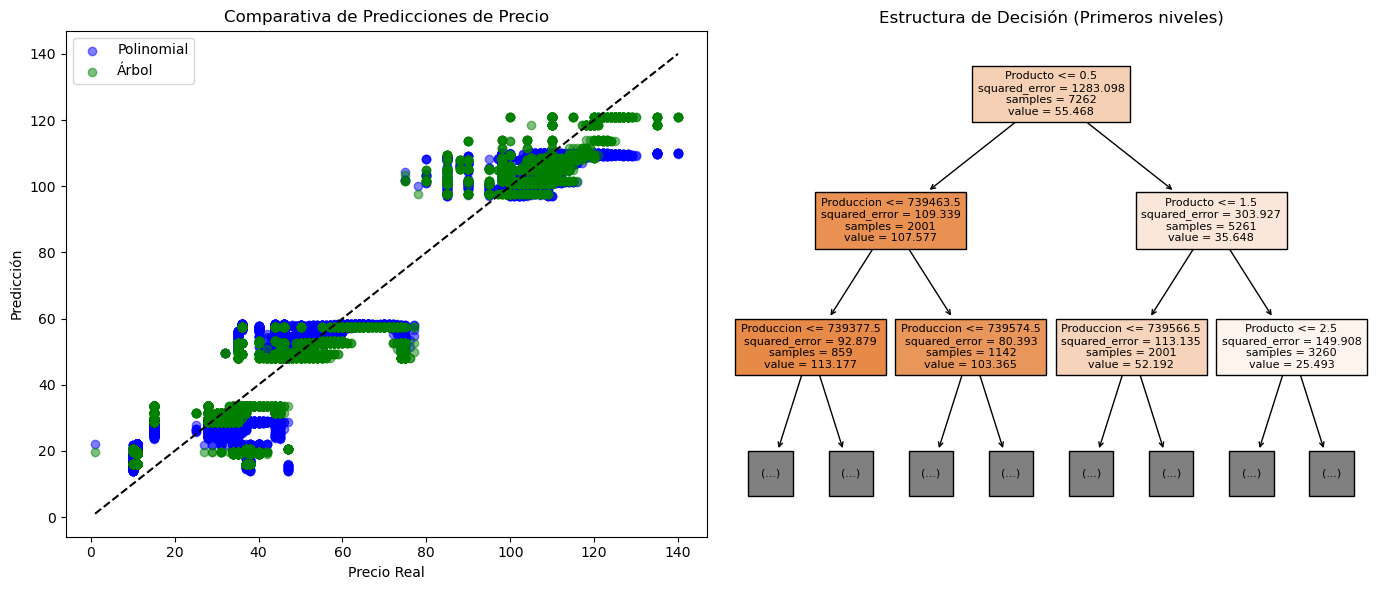

In [6]:
def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df_sheet in dict_hojas.items():
            df_sheet.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in col[1] else col[0] for col in df_sheet.columns]
            df_sheet = df_sheet.rename(columns={df_sheet.columns[0]: 'Fecha'})
            df_sheet['Fecha'] = pd.to_datetime(df_sheet['Fecha'], format='%Y-%m-%d', errors='coerce')
            df_sheet = df_sheet.dropna(subset=['Fecha'])
            lista_df.append(df_sheet)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f"Error al abrir el Excel: {e}")
        return None

response_excel = requests.get(url_excel)
df_base = cargar_datos_limpios(BytesIO(response_excel.content))

freq_cols = [col for col in df_base.columns if '_Frecc' in col]

df_temp = df_base[['Fecha'] + freq_cols].copy()
df_temp.columns = ['Fecha'] + [col.replace('_Frecc', '') for col in freq_cols]
df_melted = df_temp.melt(id_vars=['Fecha'], var_name='Producto', value_name='Precio')

df_melted['Precio'] = df_melted['Precio'].apply(limpiar_dinero)
df_melted = df_melted.dropna(subset=['Precio'])

df_melted['Produccion'] = df_melted['Fecha'].apply(lambda x: x.toordinal())
df = df_melted.groupby('Producto').filter(lambda x: len(x) > 10).copy()

df['Producto_cat'] = df['Producto'].astype('category').cat.codes
X = df[['Produccion', 'Producto_cat']].values
y = df['Precio'].values

# --- MODELO A: REGRESIÓN POLINOMIAL ---
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)

# --- MODELO B: ÁRBOL DE DECISIÓN ---
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X, y)
y_tree_pred = tree_model.predict(X)

# --- COMPARACIÓN DE MÉTRICAS ---
print(f"R2 Polinomial: {r2_score(y, y_poly_pred):.4f}")
print(f"R2 Árbol de Decisión: {r2_score(y, y_tree_pred):.4f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y, y_poly_pred, alpha=0.5, label='Polinomial', color='blue')
plt.scatter(y, y_tree_pred, alpha=0.5, label='Árbol', color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--k')
plt.title('Comparativa de Predicciones de Precio')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')
plt.legend()

plt.subplot(1, 2, 2)
plot_tree(tree_model, feature_names=['Produccion', 'Producto'],
          filled=True, fontsize=8, max_depth=2)
plt.title('Estructura de Decisión (Primeros niveles)')
plt.tight_layout()
plt.show()

## Modelado y procesamiento mátematico

### Predicción de precios mediante regresión polinomial:

> La siguiente sección se sustenta bajo los conocimientos de la UCA de Modelos Estocásticos


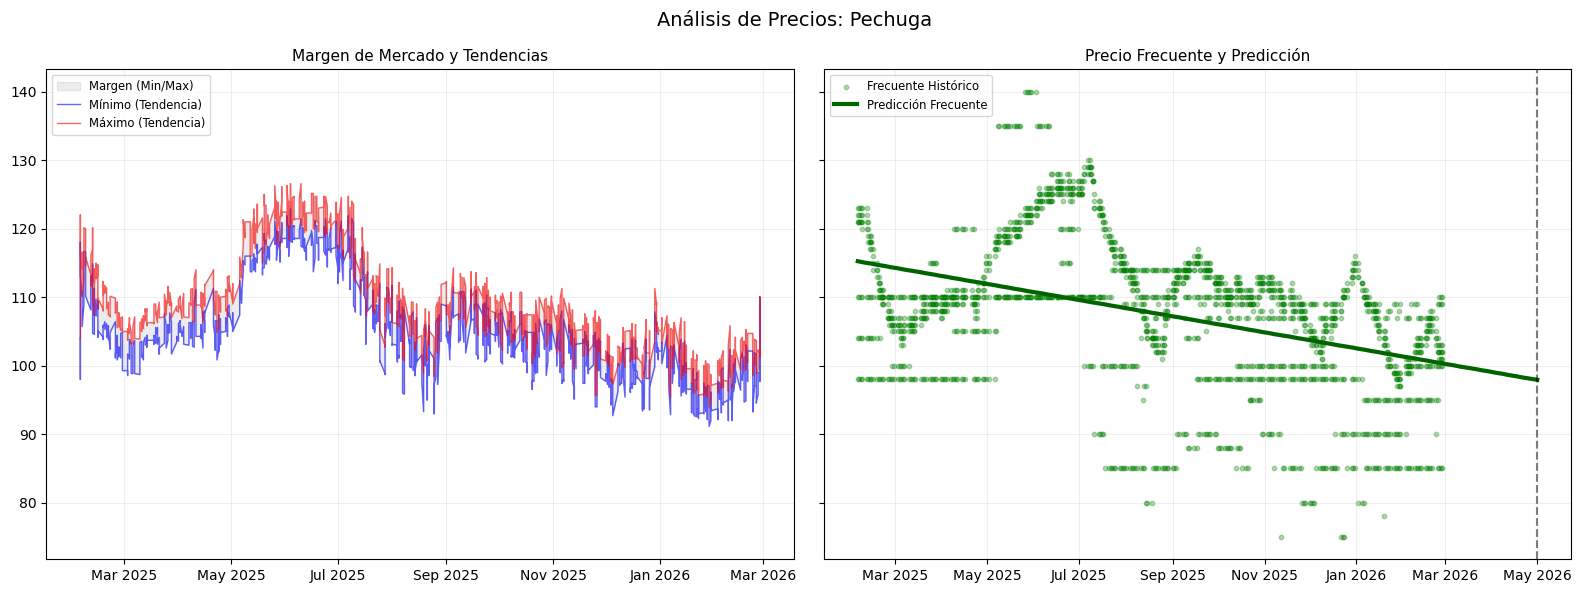

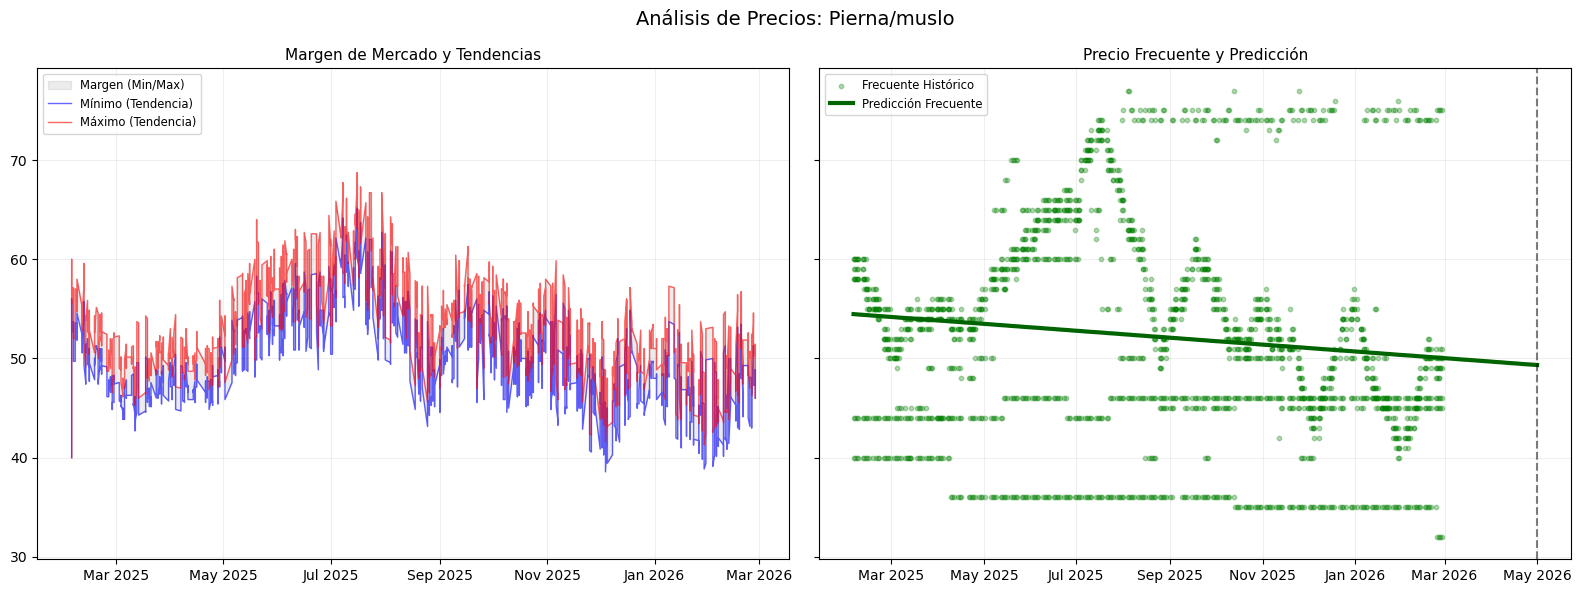

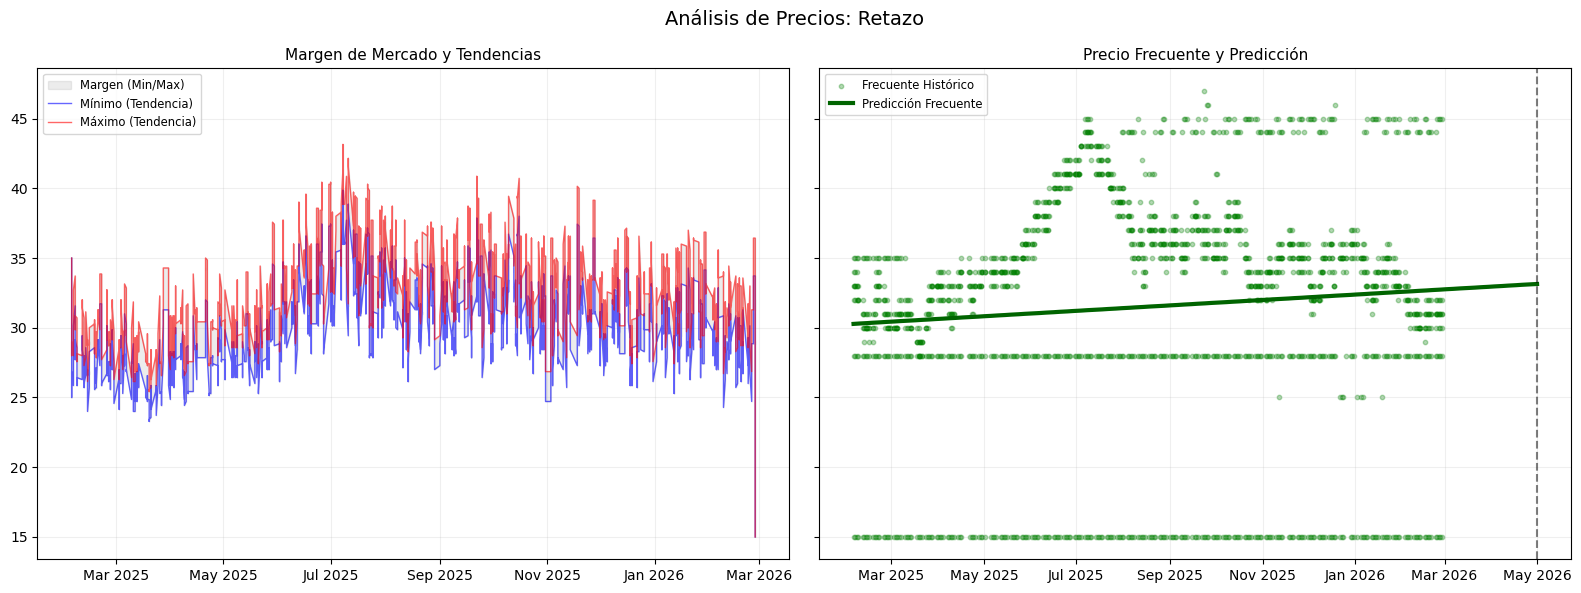

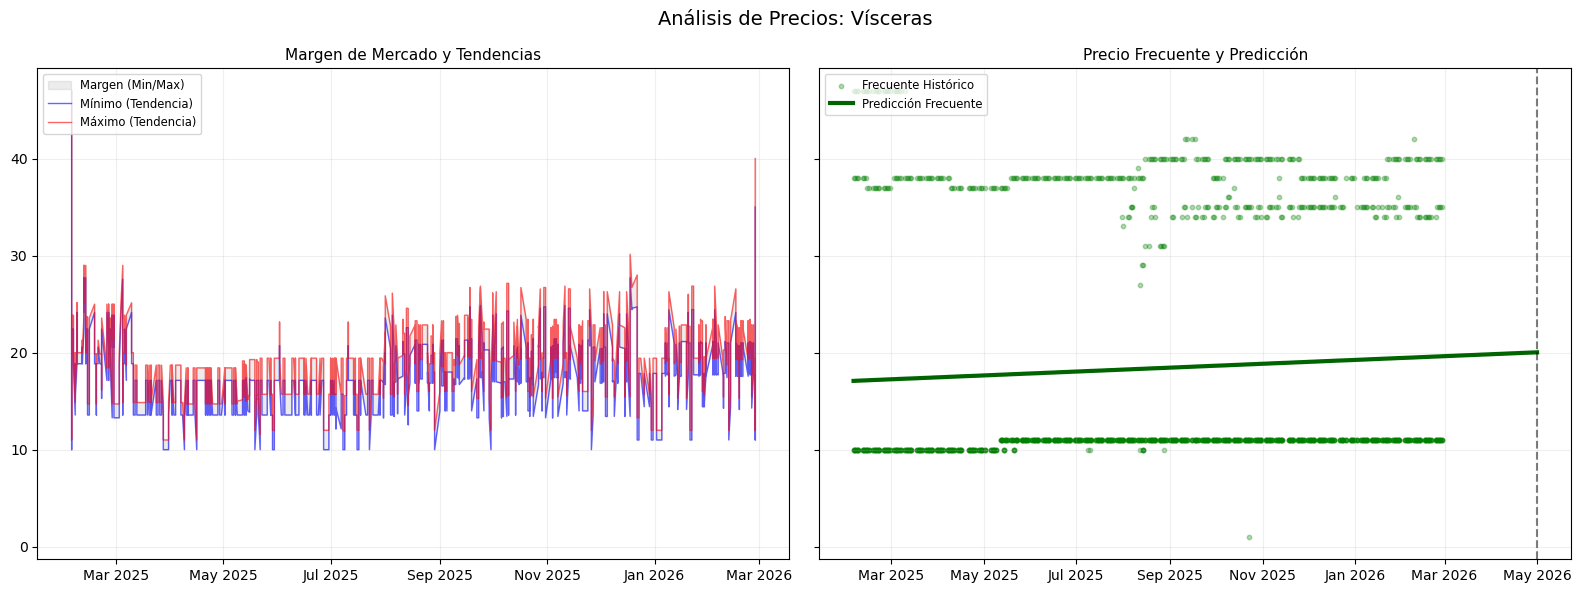

In [7]:
response = requests.get(url_excel)
df_base = cargar_datos_limpios(BytesIO(response.content))

if df_base is not None:
    piezas = [c.replace('_Min', '') for c in df_base.columns if '_Min' in c]
    fecha_proyectada = datetime(2026, 5, 1)
    ord_proyectada = fecha_proyectada.toordinal()

    for pieza in piezas:
        try:
            col_frec = [c for c in df_base.columns if pieza in c and 'Fre' in c][0]
            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Min': df_base[f'{pieza}_Min'].apply(limpiar_dinero),
                'Max': df_base[f'{pieza}_Max'].apply(limpiar_dinero),
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna().sort_values('Fecha')

            if len(df_p) < 10: continue

            df_p['F_Smooth'] = df_p['Frec'].rolling(window=7, center=True).mean().fillna(df_p['Frec'])
            df_p['Min_Smooth'] = df_p['Min'].rolling(window=7, center=True).mean().fillna(df_p['Min'])
            df_p['Max_Smooth'] = df_p['Max'].rolling(window=7, center=True).mean().fillna(df_p['Max'])

            X = df_p['Fecha'].map(datetime.toordinal).values.reshape(-1, 1)
            y = df_p['F_Smooth'].values

            poly = PolynomialFeatures(degree=1)
            X_poly = poly.fit_transform(X)
            modelo = Ridge(alpha=1.0).fit(X_poly, y)

            # --- SUBPLOTS EN PARALELO ---
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

            ax1.fill_between(df_p['Fecha'], df_p['Min_Smooth'], df_p['Max_Smooth'],
                             color='gray', alpha=0.15, label='Margen (Min/Max)')
            ax1.plot(df_p['Fecha'], df_p['Min_Smooth'], color='blue', alpha=0.6, linewidth=1, label='Mínimo (Tendencia)')
            ax1.plot(df_p['Fecha'], df_p['Max_Smooth'], color='red', alpha=0.6, linewidth=1, label='Máximo (Tendencia)')
            
            ax1.set_title("Margen de Mercado y Tendencias", fontsize=11)
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            ax1.grid(True, alpha=0.2)
            ax1.legend(loc='upper left', fontsize='small')

            ax2.scatter(df_p['Fecha'], df_p['Frec'], color='green', s=10, alpha=0.3, label='Frecuente Histórico')
            
            fechas_X = np.linspace(X.min(), ord_proyectada, 100).reshape(-1, 1)
            preds_Y = modelo.predict(poly.transform(fechas_X))
            fechas_plot = [datetime.fromordinal(int(d)) for d in fechas_X]
            
            ax2.plot(fechas_plot, preds_Y, color='darkgreen', linewidth=3, label='Predicción Frecuente')
            
            ax2.set_title("Precio Frecuente y Predicción", fontsize=11)
            ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            ax2.axvline(fecha_proyectada, color='black', linestyle='--', alpha=0.5)
            ax2.grid(True, alpha=0.2)
            ax2.legend(loc='upper left', fontsize='small')

            fig.suptitle(f"Análisis de Precios: {pieza}", fontsize=14, y=0.98)
            
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error en {pieza}: {e}")

### Predicción de precios mediante regresión lineal

Pronósticos basados en datos del 2025-08-27 al 2026-02-27:

Pieza: Pechuga
 - Pronóstico para 2026-02-28: $98.05
Pieza: Pierna/muslo
 - Pronóstico para 2026-02-28: $47.13
Pieza: Retazo
 - Pronóstico para 2026-02-28: $30.48
Pieza: Vísceras
 - Pronóstico para 2026-02-28: $19.35


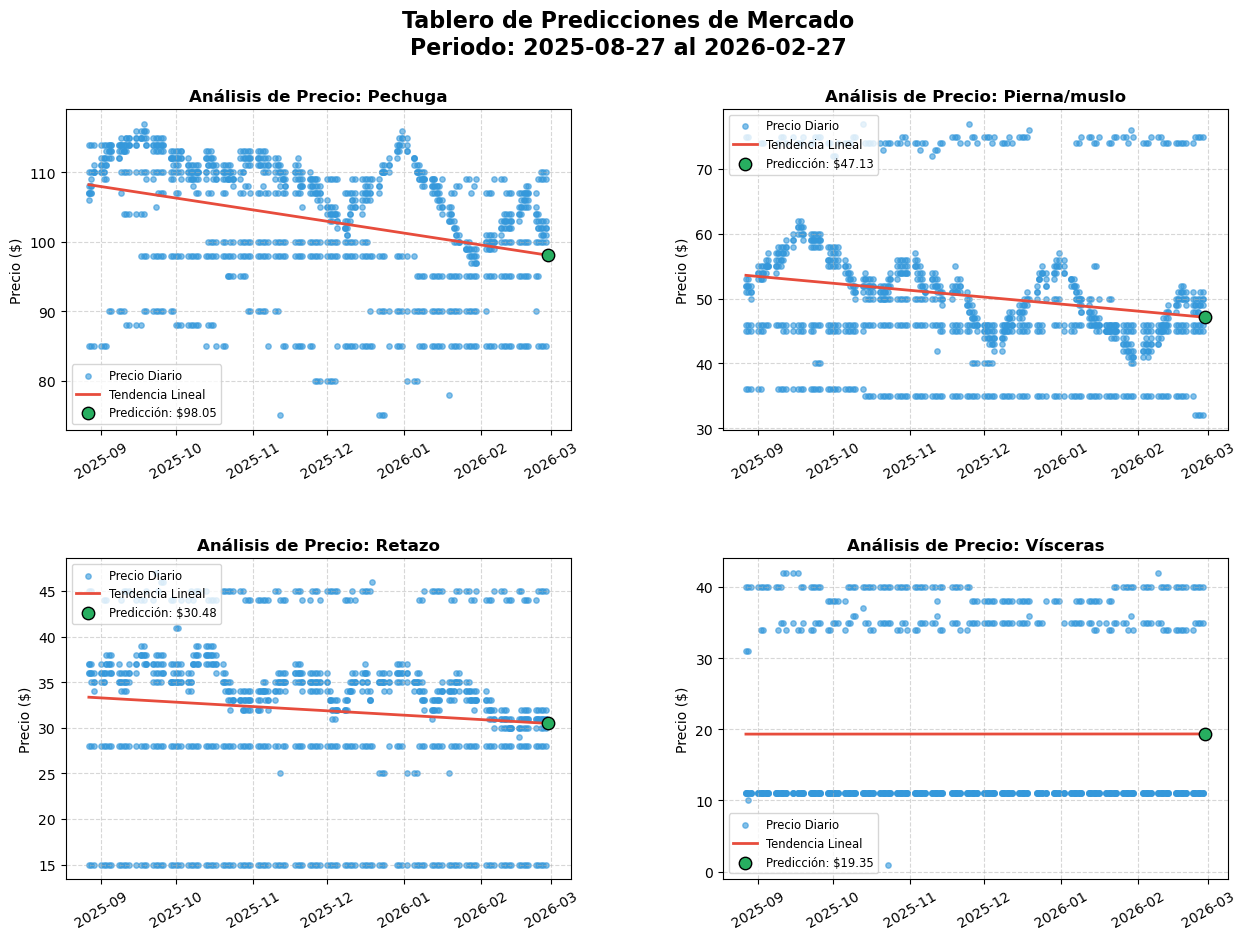

In [8]:
"""
Solo toma en cuenta los últimos 6 meses de datos para que la predicción sea sensible
a las tendencias recientes del mercado
"""
df_base['Fecha'] = pd.to_datetime(df_base['Fecha'])

fecha_maxima = df_base['Fecha'].max()
fecha_inicio = fecha_maxima - pd.DateOffset(months=6)
df_filtrado  = df_base[df_base['Fecha'] >= fecha_inicio].copy()

piezas = ['Pechuga', 'Pierna/muslo', 'Retazo', 'Vísceras']

print(f"Pronósticos basados en datos del {fecha_inicio.date()} al {fecha_maxima.date()}:\n")

for pieza in piezas:
    freq_col_name = f"{pieza}_Frecc"
    if freq_col_name not in df_base.columns:
        print(f"No se encontró columna '{freq_col_name}' para {pieza}. Saltando.\n")
        continue

    datos_pieza = df_filtrado[['Fecha', freq_col_name]].copy()
    datos_pieza['Precio'] = datos_pieza[freq_col_name].apply(limpiar_dinero)
    datos_pieza = datos_pieza.dropna(subset=['Precio'])

    if len(datos_pieza) > 1:
        X = datos_pieza['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
        y = datos_pieza['Precio'].values

        modelo = LinearRegression()
        modelo.fit(X, y)

        fecha_proxima = fecha_maxima + timedelta(days=1)
        X_proxima  = np.array([[fecha_proxima.toordinal()]])
        prediccion = modelo.predict(X_proxima)[0]

        print(f"Pieza: {pieza}")
        print(f" - Pronóstico para {fecha_proxima.date()}: ${prediccion:.2f}")
    else:
        print(f"Pieza: {pieza} - Datos insuficientes para los últimos 6 meses.")

# --- TABLERO (2 filas x 2 columnas) ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, pieza in enumerate(piezas):
    ax            = axes[i]
    freq_col_name = f"{pieza}_Frecc"

    if freq_col_name not in df_base.columns:
        ax.set_title(f"{pieza}: Columna no encontrada")
        continue

    datos_pieza = df_filtrado[['Fecha', freq_col_name]].copy()
    datos_pieza['Precio'] = datos_pieza[freq_col_name].apply(limpiar_dinero)
    datos_pieza = datos_pieza.dropna(subset=['Precio'])

    if len(datos_pieza) > 1:
        X = datos_pieza['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
        y = datos_pieza['Precio'].values

        modelo      = LinearRegression()
        modelo.fit(X, y)
        y_tendencia = modelo.predict(X)

        fecha_proxima = fecha_maxima + timedelta(days=1)
        X_proxima  = np.array([[fecha_proxima.toordinal()]])
        prediccion = modelo.predict(X_proxima)[0]

        ax.scatter(datos_pieza['Fecha'], y, color='#3498db', s=15, alpha=0.6, label='Precio Diario')
        ax.plot(datos_pieza['Fecha'], y_tendencia, color='#e74c3c', lw=2, label='Tendencia Lineal')
        ax.scatter(fecha_proxima, prediccion, color='#27ae60', s=80, edgecolors='black',
                   label=f'Predicción: ${prediccion:.2f}', zorder=5)

        ax.set_title(f'Análisis de Precio: {pieza}', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precio ($)')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize='small')
    else:
        ax.set_title(f"{pieza}: Datos insuficientes")

plt.suptitle(f"Tablero de Predicciones de Mercado\nPeriodo: {fecha_inicio.date()} al {fecha_maxima.date()}",
             fontsize=16, fontweight='heavy')
plt.show()

### Árboles de decisión de Compra/Venta por pieza:

> La siguiente sección se sustenta bajo los conocimientos de la UCA de Machine Learning

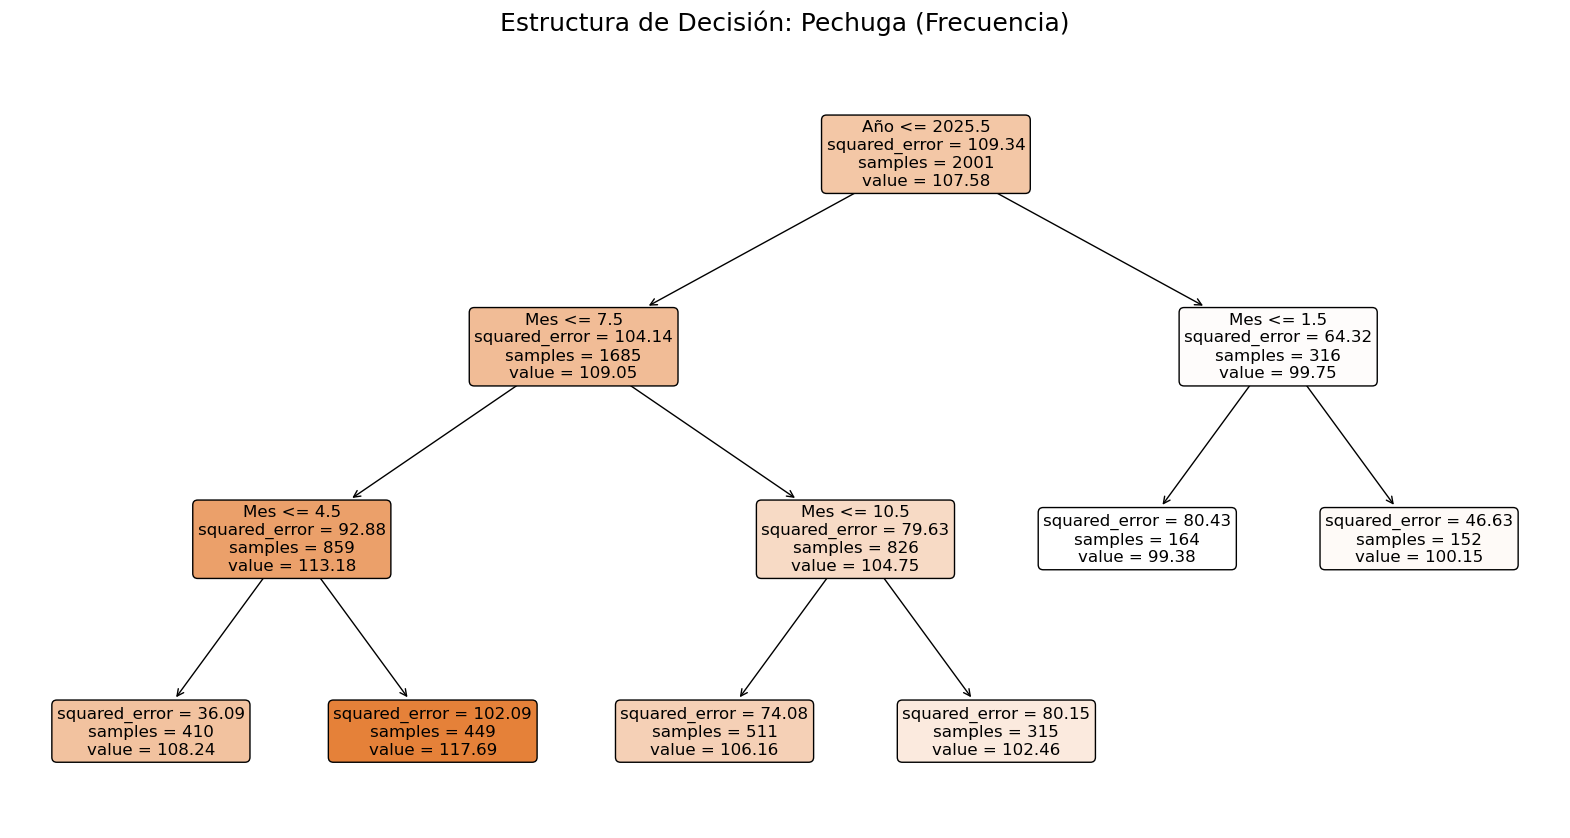


 Predicción estimada para Mayo 2026: $100.15


/opt/conda/lib/python3.11/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [9]:
PIEZA_OBJETIVO = 'Pechuga'
"""Piezas disponibles: Pierna/muslo, Vísceras, Retazo, Pechuga
Solo se necesita cambiar el valor de PIEZA_OBJETIVO
"""

df_base = cargar_datos_limpios(url_excel)

if df_base is not None:
    try:
        col_frec = [c for c in df_base.columns if PIEZA_OBJETIVO in c and 'Fre' in c][0]

        df_base[col_frec]  = df_base[col_frec].apply(limpiar_dinero)
        df_base['Año']     = df_base['Fecha'].dt.year
        df_base['Mes']     = df_base['Fecha'].dt.month
        df_base            = df_base.dropna(subset=['Año', 'Mes', col_frec])

        modelo_legible = DecisionTreeRegressor(max_depth=3, random_state=42)
        modelo_legible.fit(df_base[['Año', 'Mes']], df_base[col_frec])

        plt.figure(figsize=(20, 10))
        plot_tree(modelo_legible,
                  feature_names=['Año', 'Mes'],
                  filled=True,
                  rounded=True,
                  precision=2,
                  fontsize=12,
                  proportion=False)
        plt.title(f"Estructura de Decisión: {PIEZA_OBJETIVO} (Frecuencia)", fontsize=18, pad=20)
        plt.show()

        fecha_proyectada = datetime(2026, 5, 1)
        pred = modelo_legible.predict([[fecha_proyectada.year, fecha_proyectada.month]])[0]
        print(f"\n Predicción estimada para Mayo 2026: ${pred:,.2f}")

    except Exception as e:
        print(f"Error al generar el árbol: {e}")

In [10]:
piezas_arbol = ['Pechuga', 'Pierna/muslo', 'Retazo', 'Visceras']

# ── Selector de fecha de prediccion ──────────────────────────────────────
lbl_fecha = widgets.HTML(
    value="<b style='color:#2c3e50'>Fecha de prediccion:</b>"
)
wi_anio = widgets.BoundedIntText(
    value=2026, min=2020, max=2035,
    description='Año:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='160px')
)
wi_mes = widgets.BoundedIntText(
    value=6, min=1, max=12,
    description='Mes:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='140px')
)
wi_dia = widgets.BoundedIntText(
    value=1, min=1, max=31,
    description='Dia:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='130px')
)
btn_arbol  = widgets.Button(
    description='Generar arboles',
    button_style='primary',
    layout=widgets.Layout(width='180px', height='34px')
)
out_arbol  = widgets.Output()

display(widgets.VBox([
    lbl_fecha,
    widgets.HBox([wi_anio, wi_mes, wi_dia],
                 layout=widgets.Layout(gap='10px')),
    widgets.HBox([btn_arbol], layout=widgets.Layout(margin='8px 0')),
    out_arbol
]))

# ── Logica ────────────────────────────────────────────────────────────────
def generar_arboles(b):
    with out_arbol:
        clear_output(wait=True)

        try:
            anio = wi_anio.value
            mes  = wi_mes.value
            dia  = wi_dia.value
            fecha_proj = datetime(anio, mes, min(dia, 28))
        except ValueError as e:
            print(f"Fecha invalida: {e}")
            return

        response_a = requests.get(url_excel)
        df_a = cargar_datos_limpios(BytesIO(response_a.content))
        if df_a is None:
            print("No se pudo cargar el dataset.")
            return

        df_a['Fecha'] = pd.to_datetime(df_a['Fecha'], errors='coerce')
        df_a = df_a.dropna(subset=['Fecha'])

        resultados = {}
        errores    = []

        for pieza in piezas_arbol:
            try:
                col_frec = next(
                    (c for c in df_a.columns if pieza.split('/')[0] in c and 'Fre' in c), None
                )
                if col_frec is None:
                    errores.append(f"{pieza}: columna no encontrada")
                    continue

                df_p = df_a[['Fecha', col_frec]].copy()
                df_p['Precio'] = df_p[col_frec].apply(limpiar_dinero)
                df_p['Anno']   = df_p['Fecha'].dt.year
                df_p['Mes_n']  = df_p['Fecha'].dt.month
                df_p = df_p.dropna(subset=['Anno', 'Mes_n', 'Precio'])

                if len(df_p) < 10:
                    errores.append(f"{pieza}: muestra insuficiente ({len(df_p)} registros)")
                    continue

                modelo = DecisionTreeRegressor(max_depth=3, random_state=42)
                modelo.fit(df_p[['Anno', 'Mes_n']], df_p['Precio'])

                pred = modelo.predict([[fecha_proj.year, fecha_proj.month]])[0]
                resultados[pieza] = {'modelo': modelo, 'pred': pred, 'n': len(df_p)}

            except Exception as e:
                errores.append(f"{pieza}: {e}")

        if not resultados:
            print("No se generaron modelos. Errores:", errores)
            return

        # ── Cuadricula de arboles ─────────────────────────────────────────
        n_cols   = 2
        n_rows   = math.ceil(len(resultados) / n_cols)
        fig_tree, axes_tree = plt.subplots(n_rows, n_cols, figsize=(22, 9 * n_rows))
        axes_tree = np.array(axes_tree).flatten()
        plt.subplots_adjust(hspace=0.35, wspace=0.12)

        for idx, (pieza, datos) in enumerate(resultados.items()):
            ax = axes_tree[idx]
            plot_tree(
                datos['modelo'],
                feature_names=['Anno', 'Mes'],
                filled=True, rounded=True,
                precision=2, fontsize=9,
                proportion=False, ax=ax
            )
            ax.set_title(
                f"{pieza}  |  n={datos['n']} registros\n"
                f"Pred. {fecha_proj.strftime('%d/%m/%Y')}: ${datos['pred']:,.2f}",
                fontsize=12, fontweight='bold', pad=12
            )

        for ax_extra in axes_tree[len(resultados):]:
            ax_extra.axis('off')

        fig_tree.suptitle(
            f"Arboles de Decision por Pieza Avicola\nFecha de prediccion: {fecha_proj.strftime('%d / %m / %Y')}",
            fontsize=16, fontweight='bold', y=1.01
        )
        plt.tight_layout()
        plt.show()

        # ── Tabla de predicciones ─────────────────────────────────────────
        print("\n" + "=" * 55)
        print(f"  PREDICCIONES PARA {fecha_proj.strftime('%d/%m/%Y')}")
        print("=" * 55)
        for pieza, datos in resultados.items():
            print(f"  {pieza:<16}  ->  ${datos['pred']:>8,.2f}  (n={datos['n']})")
        if errores:
            print("\n  Advertencias:")
            for e in errores:
                print(f"    - {e}")
        print("=" * 55)

        # ── Comparativa visual de predicciones ────────────────────────────
        nombres = list(resultados.keys())
        valores = [resultados[p]['pred'] for p in nombres]
        colores = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12'][:len(nombres)]

        fig_bar, ax_bar = plt.subplots(figsize=(10, 4))
        bars = ax_bar.barh(nombres, valores, color=colores, alpha=0.82, edgecolor='white', height=0.5)
        ax_bar.bar_label(bars, fmt='$%.2f', padding=6, fontsize=11, fontweight='bold')
        ax_bar.set_xlabel('Precio Predicho ($)', fontsize=10)
        ax_bar.set_title(
            f"Comparativa de Predicciones por Pieza — {fecha_proj.strftime('%d/%m/%Y')}",
            fontsize=12, fontweight='bold'
        )
        ax_bar.set_xlim(0, max(valores) * 1.25)
        ax_bar.grid(True, axis='x', linestyle='--', alpha=0.4)
        ax_bar.invert_yaxis()
        plt.tight_layout()
        plt.show()

btn_arbol.on_click(generar_arboles)

#### Estructura de interfaz simplifficada preeliminar de usuario basada en el decision tree:

In [11]:
def obtener_datos():
    response = requests.get(url_excel)
    dict_hojas = pd.read_excel(BytesIO(response.content), sheet_name=None, header=[1, 2])
    lista_df = []
    for nombre, df in dict_hojas.items():
        df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in col[1] else col[0] for col in df.columns]
        df = df.rename(columns={df.columns[0]: 'Fecha'})
        df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
        lista_df.append(df.dropna(subset=['Fecha']))
    return pd.concat(lista_df, ignore_index=True)

def limpiar_valor(v):
    try: return float(str(v).replace('$', '').replace(',', '').strip())
    except: return np.nan

df_base          = obtener_datos()
opciones_productos = [c.replace('_Min', '') for c in df_base.columns if '_Min' in c]

fecha_ui  = widgets.DatePicker(description='Fecha:', value=datetime.now())
precio_ui = widgets.FloatText(description='Precio ($):', value=0.0)
prod_ui   = widgets.Dropdown(options=opciones_productos, description='Producto:')
btn_ui    = widgets.Button(description="Generar Recomendación", button_style='success')
output_ui = widgets.Output()

def logic_decision(actual, predicho):
    if actual <= predicho:
        return f"'\033[32m' COMPRAR. El precio es bajo (${actual:.2f}) comparado con la tendencia (${predicho:.2f})."
    else:
        return f" '\033[31m'  VENDER/ESPERAR. El precio está inflado (${actual:.2f}) respecto a la predicción (${predicho:.2f})."

def procesar_analisis(b):
    with output_ui:
        clear_output()
        if precio_ui.value <= 0:
            print("Por favor, ingresa un precio válido.")
            return

        col_frec = [c for c in df_base.columns if prod_ui.value in c and 'Fre' in c][0]
        df_p = pd.DataFrame({
            'X': df_base['Fecha'].map(datetime.toordinal),
            'y': df_base[col_frec].apply(limpiar_valor)
        }).dropna()

        poly    = PolynomialFeatures(degree=1)
        X_train = poly.fit_transform(df_p[['X']])
        modelo  = Ridge().fit(X_train, df_p['y'])

        fecha_target = poly.transform([[fecha_ui.value.toordinal()]])
        prediccion   = modelo.predict(fecha_target)[0]

        print(f"--- Árbol de Decisión para {prod_ui.value} ---")
        print(logic_decision(precio_ui.value, prediccion))

btn_ui.on_click(procesar_analisis)
display(prod_ui, fecha_ui, precio_ui, btn_ui, output_ui)

/tmp/ipykernel_675/2520185381.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/2520185381.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/2520185381.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/2520185381.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure p

Dropdown(description='Producto:', options=('Pechuga', 'Pierna/muslo', 'Retazo', 'Vísceras'), value='Pechuga')

DatePicker(value=datetime.datetime(2026, 5, 29, 23, 36, 20, 623057), description='Fecha:', step=1)

FloatText(value=0.0, description='Precio ($):')

Button(button_style='success', description='Generar Recomendación', style=ButtonStyle())

Output()

## Comportamiendo de mercado avícola y de precios

> La siguiente sección se sustenta bajo los conocimientos de la UCA de Marketing

/tmp/ipykernel_675/985256550.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/985256550.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/985256550.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/985256550.py:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure p


     TABLERO DE DIAGNÓSTICO MATEMÁTICO PARA ESTRATEGIAS DE MARKETING

PRODUCTO / PIEZA: PECHUGA
  -> $140.02 (Precio estimado a 30 días con Black-Scholes)
  -> Volatilidad comercial calculada: 12.68%
  -> Comportamiento Dinámico (Lyapunov): Inestable (Tendencia Disruptiva)
  -> ESTRATEGIA RECOMENDADA:
     [PRECIOS DINÁMICOS] Estabilidad con volatilidad moderada. Utilizar franjas de precio psicológico
     (terminaciones .99) y marketing directo resaltar frescura y origen local.

PRODUCTO / PIEZA: PIERNA/MUSLO
  -> $160.51 (Precio estimado a 30 días con Black-Scholes)
  -> Volatilidad comercial calculada: 28.91%
  -> Comportamiento Dinámico (Lyapunov): Estable (Maduro)
  -> ESTRATEGIA RECOMENDADA:
     [ESTRATEGIA DE VOLUMEN / FIDELIZACIÓN] Mercado maduro con precios fijos o decrecientes.
     Implementar cupones de descuento por volumen (ej. kg adicionales) para limpiar stock rápido.

PRODUCTO / PIEZA: RETAZO
  -> $505.82 (Precio estimado a 30 días con Black-Scholes)
  -> Volatilidad

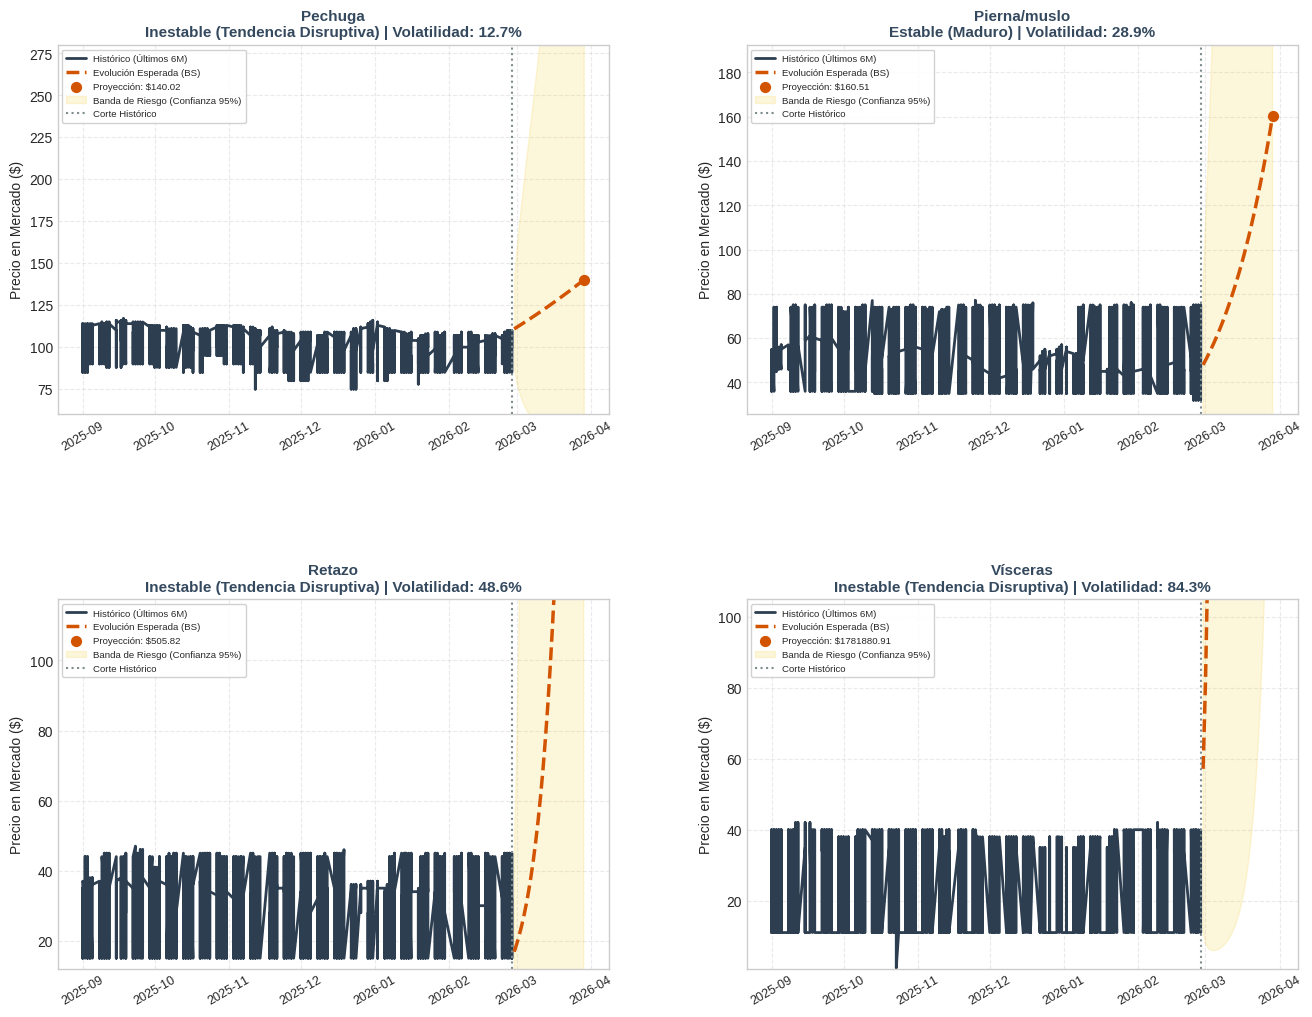

In [12]:
def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float)):
        return float(valor)
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except ValueError:
        return np.nan

def simular_black_scholes_tendencia(precios_historicos, dias_futuros=30):
    precios  = np.array(precios_historicos)
    retornos = np.log(precios[1:] / precios[:-1])
    mu       = np.mean(retornos)
    sigma    = np.std(retornos) or 0.01
    S0       = precios[-1]
    t        = np.arange(1, dias_futuros + 1)
    precio_esperado = S0 * np.exp((mu + 0.5 * sigma**2) * t)
    banda_superior  = precio_esperado * np.exp(1.96 * sigma * np.sqrt(t))
    banda_inferior  = precio_esperado * np.exp(-1.96 * sigma * np.sqrt(t))
    return t, precio_esperado, banda_superior, banda_inferior, mu, sigma

def analizar_estabilidad_lyapunov(precios_historicos, precio_equilibrio, alfa=0.1):
    precios       = np.array(precios_historicos)
    error_actual  = precios[-1] - precio_equilibrio
    cambio_precio = precios[-1] - precios[-2] if len(precios) > 1 else 0
    dV_dt         = error_actual * cambio_precio
    estabilidad   = "Estable (Maduro)" if dV_dt <= 0 else "Inestable (Tendencia Disruptiva)"
    return dV_dt, estabilidad

def cargar_datos_marketing(ruta):
    """Variante de carga con normalización de columna _Frecc y soporte de columnas sin nombre."""
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df   = []
        for nombre, df in dict_hojas.items():
            new_columns = []
            for col in df.columns:
                if 'Unnamed' not in col[1] and col[0] is not None:
                    new_columns.append(f"{col[0]}_{col[1]}")
                elif col[0] is not None:
                    new_columns.append(col[0])
                else:
                    new_columns.append(f"Unnamed_{df.columns.get_loc(col)}")
            df.columns = new_columns
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            lista_df.append(df.dropna(subset=['Fecha']))
        df_concat = pd.concat(lista_df, ignore_index=True)
        df_concat = df_concat.rename(columns=lambda x: x.replace('_Frec', '_Frecc') if x.endswith('_Frec') else x)
        return df_concat
    except Exception as e:
        print(f"Error al abrir: {e}")
        return None

response = requests.get(url_excel)
df_base  = cargar_datos_marketing(BytesIO(response.content))
df_base['Fecha'] = pd.to_datetime(df_base['Fecha'], errors='coerce')
df_base  = df_base.dropna(subset=['Fecha']).sort_values('Fecha')

piezas           = ["Pechuga", "Pierna/muslo", "Retazo", "Vísceras"]
dias_a_predecir  = 30
fecha_maxima     = df_base['Fecha'].max()
dashboard_marketing = {}

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.5, wspace=0.25)

for i, pieza in enumerate(piezas):
    ax            = axes[i]
    freq_col_name = f"{pieza}_Frecc"

    if freq_col_name not in df_base.columns:
        ax.text(0.5, 0.5, f"Columna '{freq_col_name}'\nno encontrada",
                ha='center', va='center', color='#c0392b', fontsize=11, fontweight='bold')
        ax.set_title(f"{pieza}", fontsize=12, fontweight='bold')
        continue

    datos_pieza = df_base[['Fecha', freq_col_name]].copy()
    datos_pieza['Precio'] = datos_pieza[freq_col_name].apply(limpiar_precio)
    datos_pieza = datos_pieza.dropna(subset=['Precio'])

    fecha_inicio    = fecha_maxima - timedelta(days=180)
    datos_filtrados = datos_pieza[datos_pieza['Fecha'] >= fecha_inicio]

    if len(datos_filtrados) > 5:
        fechas_hist  = datos_filtrados['Fecha'].values
        precios_hist = datos_filtrados['Precio'].values

        t_futuro, p_esp, b_sup, b_inf, mu, sigma = simular_black_scholes_tendencia(precios_hist, dias_futuros=dias_a_predecir)
        precio_medio_mercado = np.mean(precios_hist)
        dV_dt, estado_estabilidad = analizar_estabilidad_lyapunov(precios_hist, precio_medio_mercado)

        fechas_futuras = [pd.to_datetime(fecha_maxima) + timedelta(days=int(d)) for d in t_futuro]

        dashboard_marketing[pieza] = {
            "Volatilidad (BS)":        f"{sigma*100:.2f}%",
            "Tendencia de Crecimiento": "Alza" if mu > 0 else "Baja/Estable",
            "Dinámica de Precios":      estado_estabilidad,
            "Precio Proyectado (30d)":  f"${p_esp[-1]:.2f}"
        }

        ax.plot(fechas_hist, precios_hist, color='#2c3e50', label='Histórico (Últimos 6M)', lw=2)
        ax.plot(fechas_futuras, p_esp, color='#d35400', linestyle='--', lw=2.5, label='Evolución Esperada (BS)')
        ax.scatter(fechas_futuras[-1], p_esp[-1], color='#d35400', s=50, zorder=5, label=f'Proyección: ${p_esp[-1]:.2f}')
        ax.fill_between(fechas_futuras, b_inf, b_sup, color='#f1c40f', alpha=0.15, label='Banda de Riesgo (Confianza 95%)')
        ax.axvline(fecha_maxima, color='#7f8c8d', linestyle=':', lw=1.5, label='Corte Histórico')

        limite_superior_y = min(np.max(precios_hist) * 2.5, np.max(p_esp) * 2)
        limite_inferior_y = max(0, np.min(precios_hist) * 0.8)
        ax.set_ylim(limite_inferior_y, limite_superior_y)

        ax.set_title(f"{pieza}\n{estado_estabilidad} | Volatilidad: {sigma*100:.1f}%", fontsize=11, fontweight='bold', color='#34495e')
        ax.set_ylabel('Precio en Mercado ($)', fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize='x-small', loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
        ax.tick_params(axis='x', rotation=30, labelsize=9)

print("\n" + "="*80)
print("     TABLERO DE DIAGNÓSTICO MATEMÁTICO PARA ESTRATEGIAS DE MARKETING")
print("="*80)
for pieza, Metricas in dashboard_marketing.items():
    print(f"\nPRODUCTO / PIEZA: {pieza.upper()}")
    print(f"  -> {Metricas['Precio Proyectado (30d)']} (Precio estimado a 30 días con Black-Scholes)")
    print(f"  -> Volatilidad comercial calculada: {Metricas['Volatilidad (BS)']}")
    print(f"  -> Comportamiento Dinámico (Lyapunov): {Metricas['Dinámica de Precios']}")
    print("  -> ESTRATEGIA RECOMENDADA:")
    if "Inestable" in Metricas['Dinámica de Precios'] and "Alza" in Metricas['Tendencia de Crecimiento']:
        print("     [MARKETING AGRESIVO] Alta disrupción al alza. Segmentar franjas horarias matutinas con\n     promociones cruzadas. El cliente asimila variaciones de precio rápido si hay combos.")
    elif "Estable" in Metricas['Dinámica de Precios'] and "Baja" in Metricas['Tendencia de Crecimiento']:
        print("     [ESTRATEGIA DE VOLUMEN / FIDELIZACIÓN] Mercado maduro con precios fijos o decrecientes.\n     Implementar cupones de descuento por volumen (ej. kg adicionales) para limpiar stock rápido.")
    else:
        print("     [PRECIOS DINÁMICOS] Estabilidad con volatilidad moderada. Utilizar franjas de precio psicológico\n     (terminaciones .99) y marketing directo resaltar frescura y origen local.")
print("\n" + "="*80)

> La siguiente sección se sustenta bajo los conocimientos de la UCA de Investigación de Operaciones

Primeros registros del DataFrame:
  mes y año  Importaciones totales Mes_Año_Fijo      Fecha
0    feb-93                 1115.0       feb-93 1993-02-01
1    mar-93                  660.0       mar-93 1993-03-01
2    may-93                  973.0       may-93 1993-05-01
3    jun-93                 1595.0       jun-93 1993-06-01
4    jul-93                 1202.0       jul-93 1993-07-01


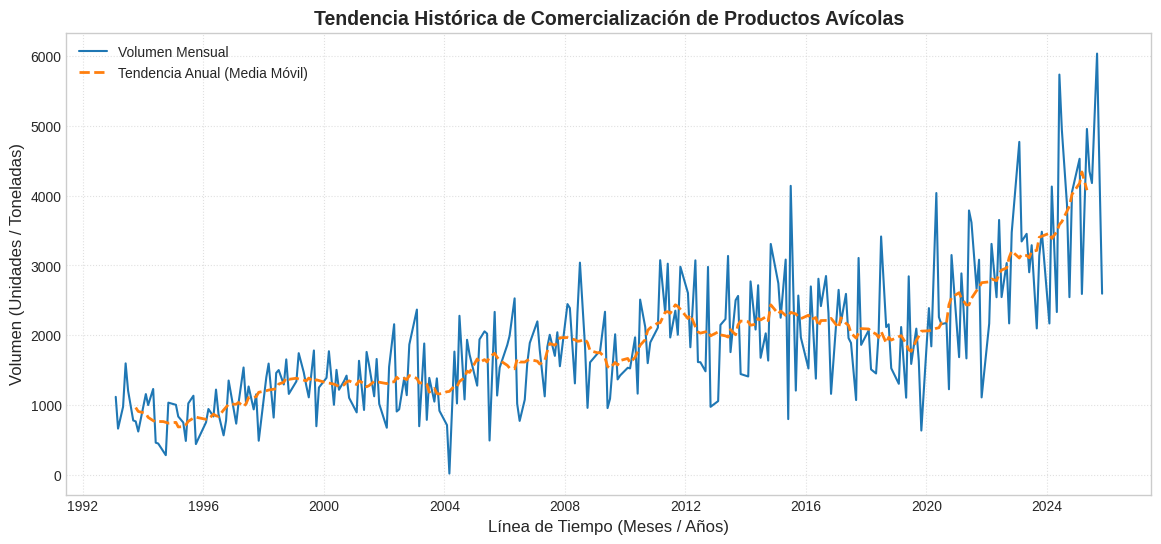

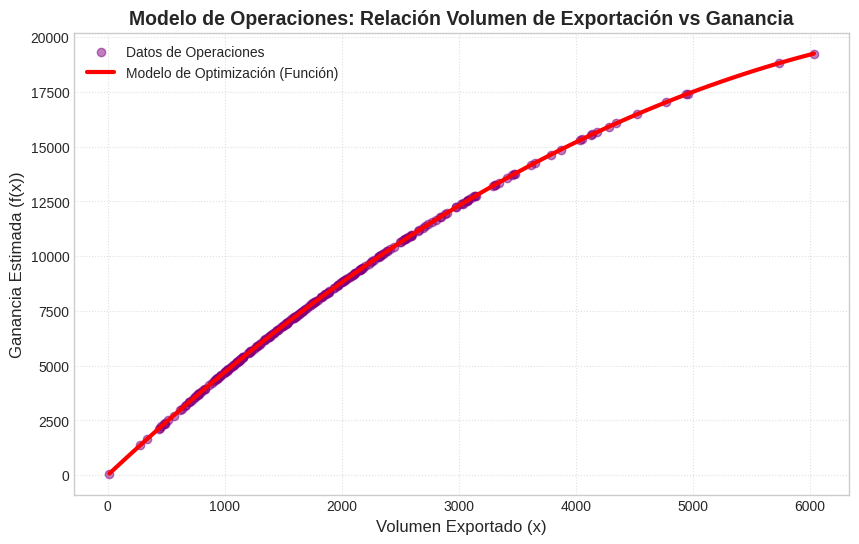


RESULTADOS DEL MODELADO MATEMÁTICO (I.O.)
La ecuación cuadrática que rige el comportamiento es:
f(x) = (-0.000300)x² + (5.0000)x + (0.0000)
--------------------------------------------------
VOLUMEN ÓPTIMO DE EXPORTACIÓN: 8333.33 unidades
GANANCIA MÁXIMA ALCANZABLE: $20833.33


In [13]:
export = "https://raw.githubusercontent.com/Naangeal01/Problema-Protot-pico-5to-sem/main/Historico%20de%20exportaciones-productos%20avicolas.csv"

response = requests.get(export)
response.encoding = 'latin1'
df = pd.read_csv(StringIO(response.text))

df['Importaciones totales'] = df['Importaciones totales'].astype(str).str.replace(',', '')
df['Importaciones totales'] = pd.to_numeric(df['Importaciones totales'], errors='coerce')
df = df.dropna()

df['Mes_Año_Fijo'] = df['mes y año'].str.strip()
df['Fecha'] = pd.to_datetime(df['Mes_Año_Fijo'], format='%b-%y', errors='coerce')
df['Fecha'] = df['Fecha'].apply(lambda x: x.replace(year=x.year - 100) if pd.notnull(x) and x.year > 2026 else x)
df = df.dropna(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

print("Primeros registros del DataFrame:")
print(df.head())

# --- Tendencia Histórica ---
plt.figure(figsize=(14, 6))
plt.plot(df['Fecha'], df['Importaciones totales'], color='#1f77b4', linewidth=1.5, label='Volumen Mensual')
plt.plot(df['Fecha'], df['Importaciones totales'].rolling(12, center=True).mean(),
         color='#ff7f0e', linestyle='--', linewidth=2, label='Tendencia Anual (Media Móvil)')
plt.title('Tendencia Histórica de Comercialización de Productos Avícolas', fontsize=14, fontweight='bold')
plt.xlabel('Línea de Tiempo (Meses / Años)', fontsize=12)
plt.ylabel('Volumen (Unidades / Toneladas)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# --- Modelado Exportación-Ganancia ---
Precio_Base = 5.0
df['Ganancia_Simulada'] = df['Importaciones totales'] * (Precio_Base - 0.0003 * df['Importaciones totales'])

X = df['Importaciones totales'].values.reshape(-1, 1)
y = df['Ganancia_Simulada'].values

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

modelo_io = LinearRegression()
modelo_io.fit(X_poly, y)

c = modelo_io.intercept_
b, a = modelo_io.coef_[1], modelo_io.coef_[2]

X_plot      = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot      = modelo_io.predict(X_plot_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='purple', alpha=0.5, label='Datos de Operaciones')
plt.plot(X_plot, y_plot, color='red', linewidth=3, label='Modelo de Optimización (Función)')
plt.title('Modelo de Operaciones: Relación Volumen de Exportación vs Ganancia', fontsize=14, fontweight='bold')
plt.xlabel('Volumen Exportado (x)', fontsize=12)
plt.ylabel('Ganancia Estimada (f(x))', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print("\n" + "="*50)
print("RESULTADOS DEL MODELADO MATEMÁTICO (I.O.)")
print("="*50)
print(f"La ecuación cuadrática que rige el comportamiento es:")
print(f"f(x) = ({a:.6f})x² + ({b:.4f})x + ({c:.4f})")
print("-"*50)
volumen_optimo  = -b / (2 * a)
ganancia_maxima = a * (volumen_optimo**2) + b * volumen_optimo + c
print(f"VOLUMEN ÓPTIMO DE EXPORTACIÓN: {volumen_optimo:.2f} unidades")
print(f"GANANCIA MÁXIMA ALCANZABLE: ${ganancia_maxima:.2f}")
print("="*50)

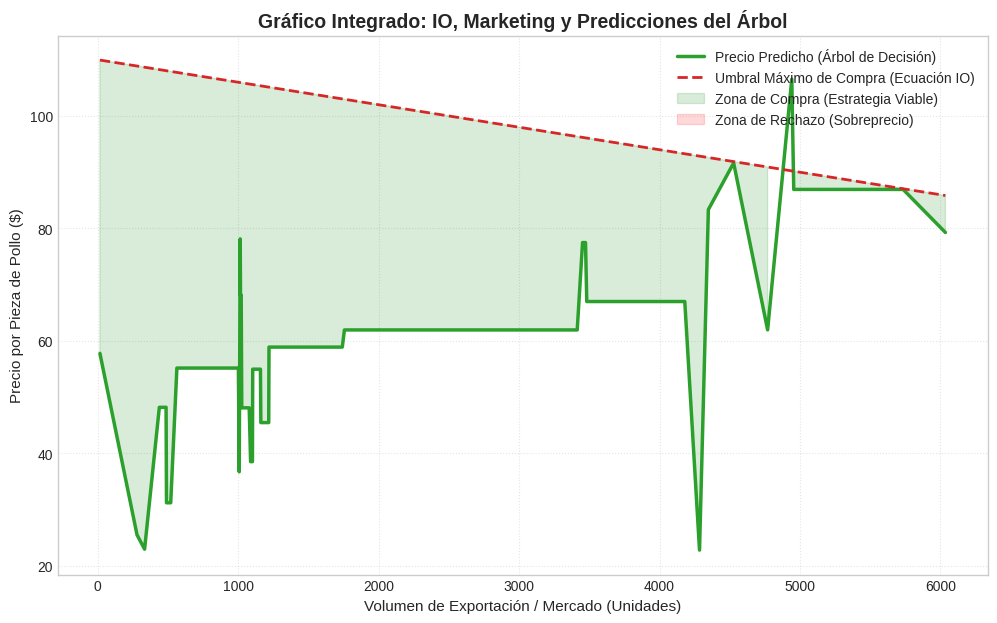

In [14]:
np.random.seed(42)
volumen_exportacion = df['Importaciones totales'].values
precios_reales = 50 + (volumen_exportacion * 0.005) + np.random.normal(0, 15, len(volumen_exportacion))

X_tree = volumen_exportacion.reshape(-1, 1)
modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arbol.fit(X_tree, precios_reales)
precios_predichos = modelo_arbol.predict(X_tree)

precio_max_aceptable = 110 - (0.004 * volumen_exportacion)

df_estrategia = pd.DataFrame({
    'Volumen': volumen_exportacion,
    'Precio_Predicho_Arbol': precios_predichos,
    'Umbral_IO_Marketing': precio_max_aceptable
}).sort_values(by='Volumen')

plt.figure(figsize=(12, 7))

plt.plot(df_estrategia['Volumen'], df_estrategia['Precio_Predicho_Arbol'],
         color='#2ca02c', linewidth=2.5, label='Precio Predicho (Árbol de Decisión)')

plt.plot(df_estrategia['Volumen'], df_estrategia['Umbral_IO_Marketing'],
         color='#d62728', linestyle='--', linewidth=2, label='Umbral Máximo de Compra (Ecuación IO)')

plt.fill_between(df_estrategia['Volumen'], df_estrategia['Precio_Predicho_Arbol'], df_estrategia['Umbral_IO_Marketing'],
                 where=(df_estrategia['Precio_Predicho_Arbol'] <= df_estrategia['Umbral_IO_Marketing']),
                 color='green', alpha=0.15, label='Zona de Compra (Estrategia Viable)')

plt.fill_between(df_estrategia['Volumen'], df_estrategia['Precio_Predicho_Arbol'], df_estrategia['Umbral_IO_Marketing'],
                 where=(df_estrategia['Precio_Predicho_Arbol'] > df_estrategia['Umbral_IO_Marketing']),
                 color='red', alpha=0.15, label='Zona de Rechazo (Sobreprecio)')

plt.title('Gráfico Integrado: IO, Marketing y Predicciones del Árbol', fontsize=14, fontweight='bold')
plt.xlabel('Volumen de Exportación / Mercado (Unidades)', fontsize=11)
plt.ylabel('Precio por Pieza de Pollo ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.show()

La integración de estas tres áreas crea una regla de negocio automatizada para compras u operaciones logísticas. El criterio se define mediante una simple resta (Optimización de Margen):
$\text{Decisión} = \text{Precio Máximo IO (Marketing)} - \text{Precio Predicho (Árbol)}$

Esta regla arooja un sistema dónde Si el resultado es ...:


... POSITIVO (Zona Verde): ¡COMPRAR!

*El Árbol de Decisión predice que el precio real de la pieza en el mercado está por debajo del valor máximo que calculó nuestra ecuación de operaciones. Marketing identifica esto como una oportunidad de alta rentabilidad u oferta, ya que estás adquiriendo el pollo a un costo menor de lo que el mercado lo valora bajo esas condiciones de exportación.*


... NEGATIVO (Zona Roja): NO COMPRAR (RECHAZAR).

*El modelo predictivo nos advierte que el precio de la pieza de pollo está inflado o sobrevalorado respecto al volumen actual de exportaciones. Operaciones sabe que comprar a ese precio romperá el margen de ganancia logística, y Marketing determina que el consumidor final no aceptará un precio tan alto si se le traslada el costo.*

Buscas los puntos del gráfico donde la línea escalonada verde (Árbol) se mantenga lo más abajo posible de la línea punteada roja (IO). Esa diferencia es dinero que tu operación ahorra de forma inteligente.



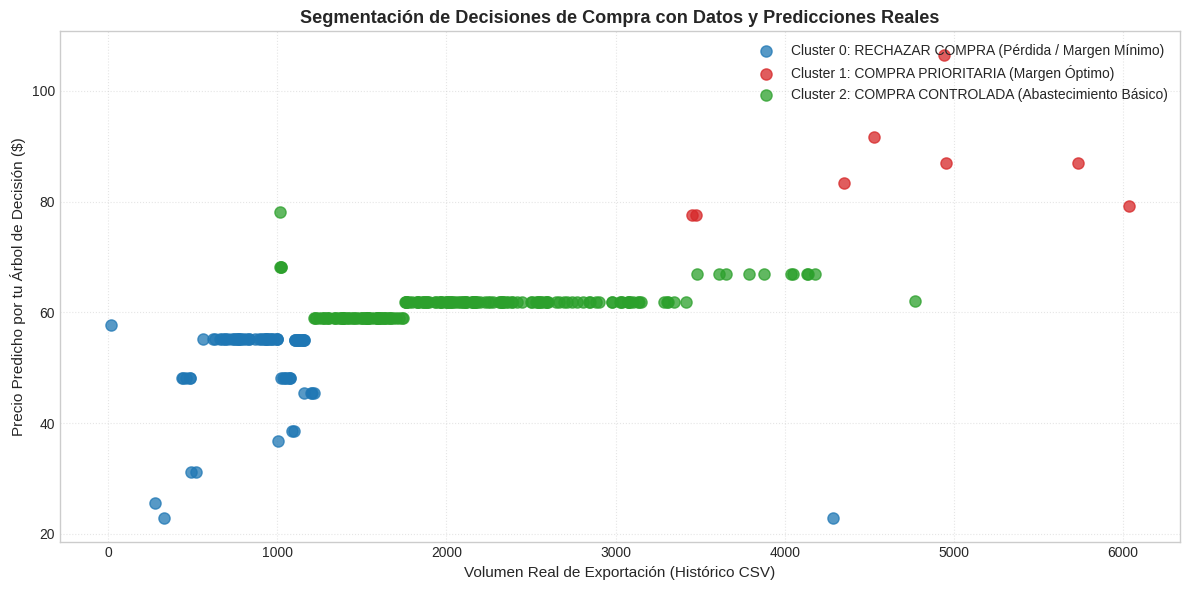


MATRIZ RECOLECTADA MEDIANTE DATA MINING (MERCADO AVÍCOLA)
         Vol_Export_Prom  Precio_Prom  Costo_Prom  Margen_Prom                       Decision_Estrategica
Cluster                                                                                                  
0             919.082192    50.831202   46.378623     4.452579  RECHAZAR COMPRA (Pérdida / Margen Mínimo)
1            4683.750000    86.212396   52.025625    34.186771         COMPRA PRIORITARIA (Margen Óptimo)
2            2148.890710    61.418529   48.223336    13.195193  COMPRA CONTROLADA (Abastecimiento Básico)


In [15]:
exportaciones_reales = df['Importaciones totales'].values
X_real = exportaciones_reales.reshape(-1, 1)
precios_reales_predichos = modelo_arbol.predict(X_real)

"""
En lugar de simularlo al azar, definimos el costo con una estructura de IO basada
en economías de escala: a mayor volumen logístico, el costo unitario de transporte baja levemente.
"""
costos_operativos_io = 45 + (exportaciones_reales * 0.0015)

margenes_reales = precios_reales_predichos - costos_operativos_io

df_data_mining = pd.DataFrame({
    'Exportacion': exportaciones_reales,
    'Precio_Predicho': precios_reales_predichos,
    'Costo_IO': costos_operativos_io,
    'Margen_Real': margenes_reales
})

scaler = StandardScaler()
X_clustering = scaler.fit_transform(df_data_mining[['Exportacion', 'Precio_Predicho', 'Margen_Real']])

kmeans_real = KMeans(n_clusters=3, random_state=42, n_init=10)
df_data_mining['Cluster'] = kmeans_real.fit_predict(X_clustering)


margenes_promedio = df_data_mining.groupby('Cluster')['Margen_Real'].mean()

def evaluar_compra_real(cluster_id):
    margen_actual = margenes_promedio[cluster_id]
    if margen_actual == margenes_promedio.max():
        return "COMPRA PRIORITARIA (Margen Óptimo)"
    elif margen_actual == margenes_promedio.min():
        return "RECHAZAR COMPRA (Pérdida / Margen Mínimo)"
    else:
        return "COMPRA CONTROLADA (Abastecimiento Básico)"

df_data_mining['Decision_Estrategica'] = df_data_mining['Cluster'].apply(evaluar_compra_real)

plt.figure(figsize=(12, 6))
colores_cluster = ['#1f77b4', '#d62728', '#2ca02c']

for cluster_id in sorted(df_data_mining['Cluster'].unique()):
    datos_cluster = df_data_mining[df_data_mining['Cluster'] == cluster_id]
    estrategia_marketing = datos_cluster['Decision_Estrategica'].iloc[0]

    plt.scatter(datos_cluster['Exportacion'], datos_cluster['Precio_Predicho'],
                s=65, color=colores_cluster[cluster_id], alpha=0.75,
                label=f'Cluster {cluster_id}: {estrategia_marketing}')

plt.title('Segmentación de Decisiones de Compra con Datos y Predicciones Reales', fontsize=13, fontweight='bold')
plt.xlabel('Volumen Real de Exportación (Histórico CSV)', fontsize=11)
plt.ylabel('Precio Predicho por tu Árbol de Decisión ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*85)
print("MATRIZ RECOLECTADA MEDIANTE DATA MINING (MERCADO AVÍCOLA)")
print("="*85)
reporte = df_data_mining.groupby('Cluster').agg({
    'Exportacion': 'mean',
    'Precio_Predicho': 'mean',
    'Costo_IO': 'mean',
    'Margen_Real': 'mean',
    'Decision_Estrategica': 'first'
}).rename(columns={'Exportacion': 'Vol_Export_Prom', 'Precio_Predicho': 'Precio_Prom', 'Costo_IO': 'Costo_Prom', 'Margen_Real': 'Margen_Prom'})
print(reporte.to_string())
print("="*85)

### Análisis de Elasticidad e Integración IO-Marketing por Pieza

/tmp/ipykernel_675/893352362.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/893352362.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/893352362.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_675/893352362.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure p

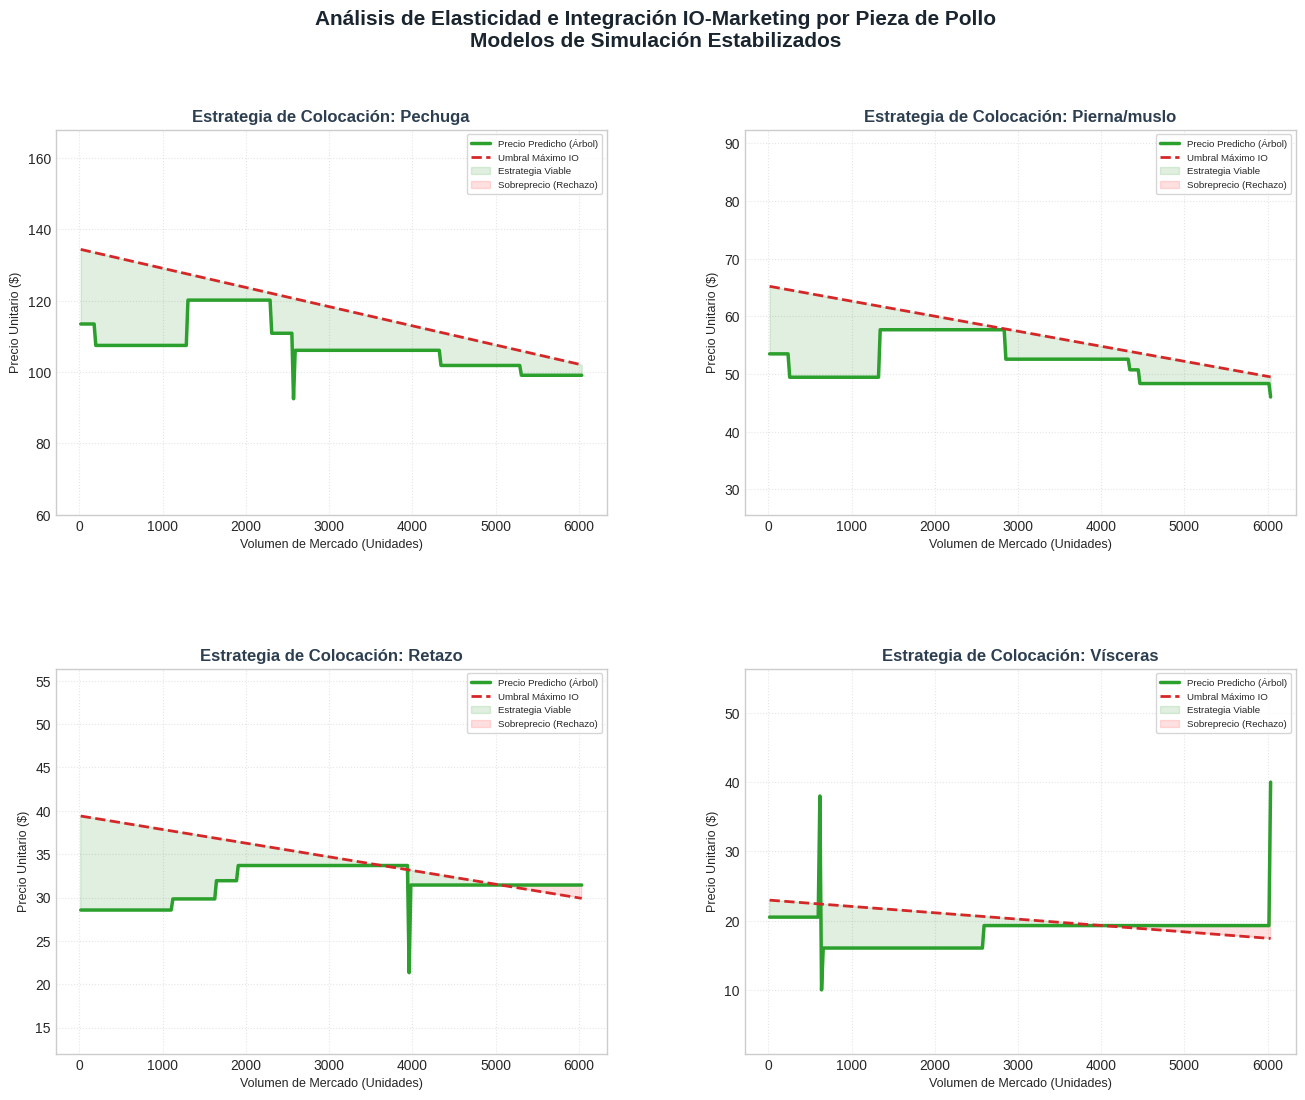

In [16]:
# --- FUNCIONES DE LIMPIEZA Y SOPORTE ---

def limpiar_precio(valor):
    if pd.isna(valor):
        return np.nan
    if isinstance(valor, (int, float)):
        return float(valor)
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except ValueError:
        return np.nan

def cargar_datos_elasticidad(ruta):
    """Carga el Excel con normalización de columnas _Frec → _Frecc."""
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            new_columns = []
            for col in df.columns:
                if 'Unnamed' not in col[1] and col[0] is not None:
                    new_columns.append(f"{col[0]}_{col[1]}")
                elif col[0] is not None:
                    new_columns.append(col[0])
                else:
                    new_columns.append(f"Unnamed_{df.columns.get_loc(col)}")
            df.columns = new_columns
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            lista_df.append(df.dropna(subset=['Fecha']))
        df_concat = pd.concat(lista_df, ignore_index=True)
        df_concat = df_concat.rename(columns=lambda x: x.replace('_Frec', '_Frecc') if x.endswith('_Frec') else x)
        return df_concat
    except Exception as e:
        print(f"Error al abrir: {e}")
        return None

# --- CARGA Y PROCESAMIENTO CON PYSPARK ---

response_export = requests.get(url_export)
response_export.encoding = 'latin1'
df_export_pd = pd.read_csv(StringIO(response_export.text))

df_export_pd['Importaciones totales'] = pd.to_numeric(
    df_export_pd['Importaciones totales'].astype(str).str.replace(',', ''), errors='coerce'
)
df_export_pd = df_export_pd.dropna(subset=['Importaciones totales'])
df_export_pd['Fecha'] = pd.to_datetime(df_export_pd['mes y año'].str.strip(), format='%b-%y', errors='coerce')
df_export_pd['Fecha'] = df_export_pd['Fecha'].apply(
    lambda x: x.replace(year=x.year - 100) if pd.notnull(x) and x.year > 2026 else x
)
df_export_pd = df_export_pd.dropna(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

response_precios = requests.get(url_excel)
df_base_pd = cargar_datos_elasticidad(BytesIO(response_precios.content))
df_base_pd['Fecha'] = pd.to_datetime(df_base_pd['Fecha'], errors='coerce')
df_base_pd = df_base_pd.dropna(subset=['Fecha']).sort_values('Fecha')

# Conversión a Spark DataFrames distribuidos
df_export_spark = spark.createDataFrame(df_export_pd)
df_base_spark   = spark.createDataFrame(df_base_pd.astype(str))

# --- TABLERO DE ELASTICIDAD IO-MARKETING POR PIEZA ---

piezas = ["Pechuga", "Pierna/muslo", "Retazo", "Vísceras"]

volumen_min = df_export_pd['Importaciones totales'].min()
volumen_max = df_export_pd['Importaciones totales'].max()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.4, wspace=0.25)

for i, pieza in enumerate(piezas):
    ax            = axes[i]
    freq_col_name = f"{pieza}_Frecc"

    if freq_col_name not in df_base_pd.columns:
        ax.text(0.5, 0.5, f"Columna '{freq_col_name}'\nno encontrada",
                ha='center', va='center', color='#c0392b', fontsize=11, fontweight='bold')
        ax.set_title(f"{pieza}", fontsize=12, fontweight='bold')
        continue

    # Extraer y limpiar serie de precios desde Spark via toPandas
    cols_pieza = ['Fecha', freq_col_name]
    datos_pieza = df_base_spark.select(cols_pieza).toPandas()
    datos_pieza['Precio_Real'] = datos_pieza[freq_col_name].apply(limpiar_precio)
    datos_pieza['Fecha'] = pd.to_datetime(datos_pieza['Fecha'], errors='coerce')
    datos_pieza = datos_pieza.dropna(subset=['Precio_Real', 'Fecha']).sort_values('Fecha')

    if len(datos_pieza) > 2:
        precios_reales  = datos_pieza['Precio_Real'].values
        volumen_pieza   = np.linspace(volumen_min, volumen_max, len(datos_pieza))
        volumen_continuo = np.linspace(volumen_min, volumen_max, 300).reshape(-1, 1)

        # Árbol de decisión sobre el espacio de volumen sintético
        modelo_arbol = DecisionTreeRegressor(max_depth=3, random_state=42)
        modelo_arbol.fit(volumen_pieza.reshape(-1, 1), precios_reales)
        precios_predichos = modelo_arbol.predict(volumen_continuo)

        # Umbral de IO adaptado al precio promedio de la pieza
        promedio_pieza       = np.mean(precios_reales)
        precio_max_aceptable = (promedio_pieza * 1.25) - ((promedio_pieza * 0.00005) * volumen_continuo.flatten())

        df_estrategia = pd.DataFrame({
            'Volumen':               volumen_continuo.flatten(),
            'Precio_Predicho_Arbol': precios_predichos,
            'Umbral_IO_Marketing':   precio_max_aceptable
        })

        ax.plot(df_estrategia['Volumen'], df_estrategia['Precio_Predicho_Arbol'],
                color='#2ca02c', linewidth=2.5, label='Precio Predicho (Árbol)')
        ax.plot(df_estrategia['Volumen'], df_estrategia['Umbral_IO_Marketing'],
                color='#d62728', linestyle='--', linewidth=2, label='Umbral Máximo IO')
        ax.fill_between(df_estrategia['Volumen'],
                        df_estrategia['Precio_Predicho_Arbol'],
                        df_estrategia['Umbral_IO_Marketing'],
                        where=(df_estrategia['Precio_Predicho_Arbol'] <= df_estrategia['Umbral_IO_Marketing']),
                        color='green', alpha=0.12, label='Estrategia Viable')
        ax.fill_between(df_estrategia['Volumen'],
                        df_estrategia['Precio_Predicho_Arbol'],
                        df_estrategia['Umbral_IO_Marketing'],
                        where=(df_estrategia['Precio_Predicho_Arbol'] > df_estrategia['Umbral_IO_Marketing']),
                        color='red', alpha=0.12, label='Sobreprecio (Rechazo)')

        ax.set_ylim(precios_reales.min() * 0.8,
                    max(precios_reales.max(), precio_max_aceptable.max()) * 1.2)
        ax.set_title(f"Estrategia de Colocación: {pieza}", fontsize=12, fontweight='bold', color='#2c3e50')
        ax.set_xlabel('Volumen de Mercado (Unidades)', fontsize=9)
        ax.set_ylabel('Precio Unitario ($)', fontsize=9)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize='7', loc='upper right', frameon=True)

    else:
        ax.text(0.5, 0.5, f"La pieza {pieza}\nno contiene registros de precio válidos",
                ha='center', va='center', color='#7f8c8d', fontsize=10, style='italic')
        ax.set_title(f"{pieza}", fontsize=12, fontweight='bold')

plt.suptitle(
    'Análisis de Elasticidad e Integración IO-Marketing por Pieza de Pollo\nModelos de Simulación Estabilizados',
    fontsize=15, fontweight='bold', color='#1a252f', y=0.98
)
plt.show()

## Exploración y análisis estadístico del DataFrame limpio

  SCHEMA DEL DATAFRAME DISTRIBUIDO (PySpark)
root
 |-- Fecha: string (nullable = true)
 |-- Pechuga_Min: double (nullable = true)
 |-- Pechuga_Max: double (nullable = true)
 |-- Pechuga_Frecc: double (nullable = true)
 |-- Pierna/muslo_Min: double (nullable = true)
 |-- Pierna/muslo_Max: double (nullable = true)
 |-- Pierna/muslo_Frecc: double (nullable = true)
 |-- Retazo_Min: double (nullable = true)
 |-- Retazo_Max: double (nullable = true)
 |-- Retazo_Frecc: double (nullable = true)
 |-- Vísceras_Min: double (nullable = true)
 |-- Vísceras_Max: double (nullable = true)
 |-- Vísceras_Frecc: double (nullable = true)


  MUESTRA DE LOS PRIMEROS 5 REGISTROS
+----------+-----------+-----------+-------------+----------------+----------------+------------------+----------+----------+------------+------------+------------+--------------+
|Fecha     |Pechuga_Min|Pechuga_Max|Pechuga_Frecc|Pierna/muslo_Min|Pierna/muslo_Max|Pierna/muslo_Frecc|Retazo_Min|Retazo_Max|Retazo_Frecc|Vísceras_Min|Vís

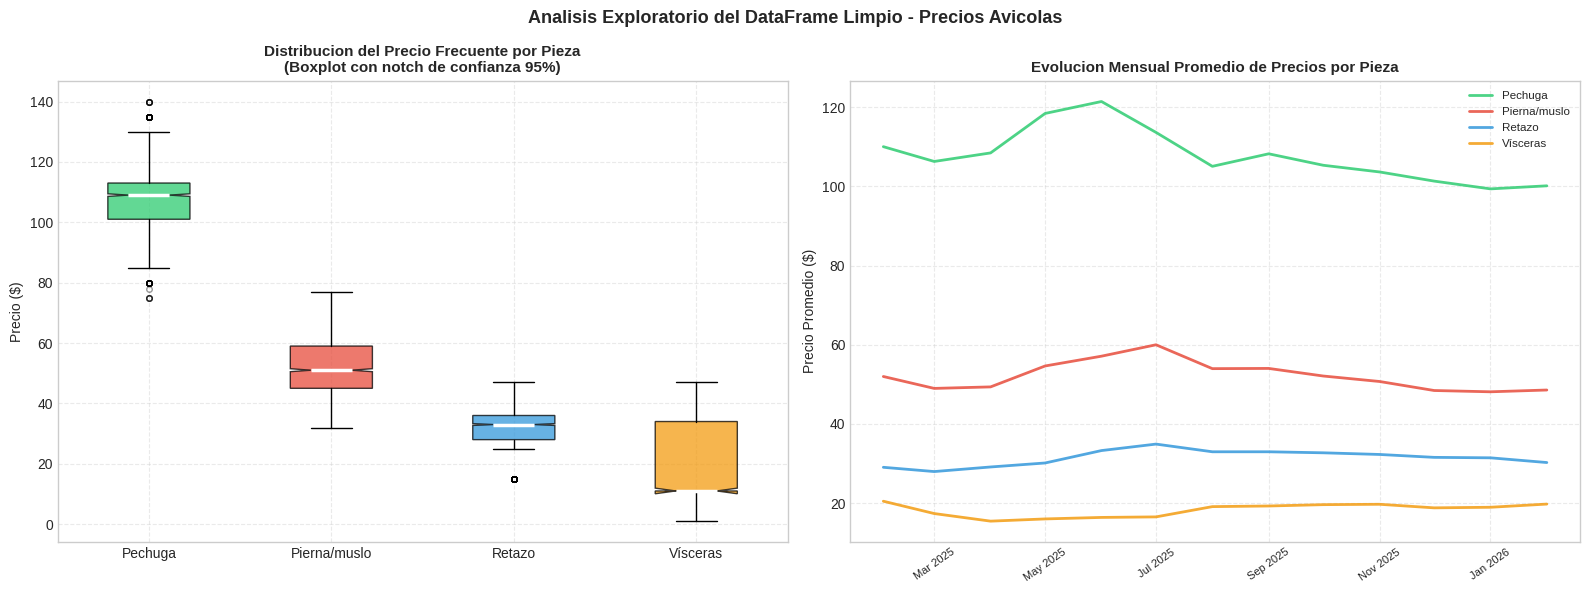

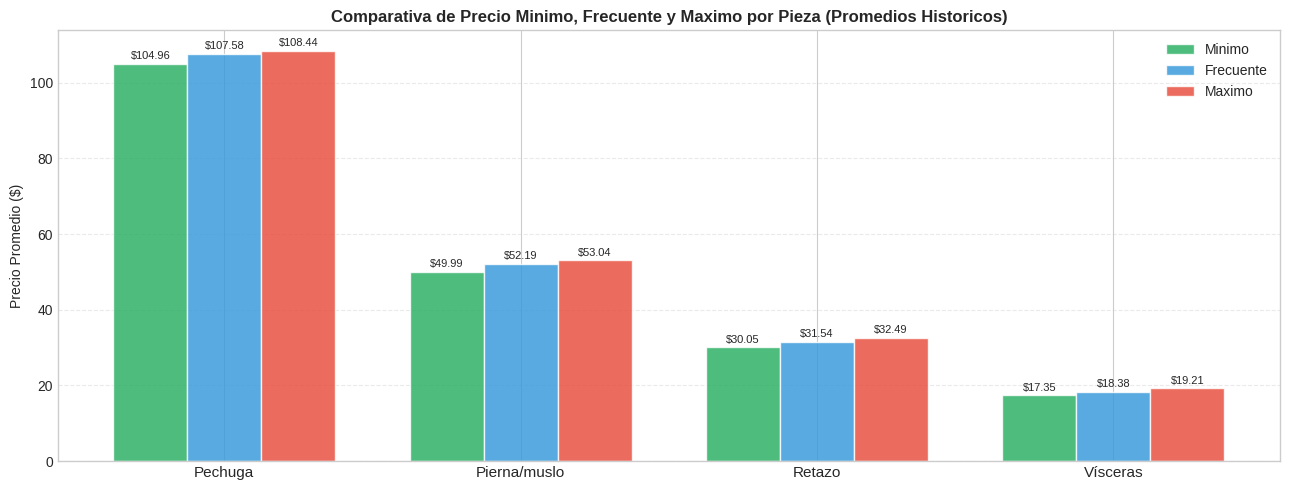

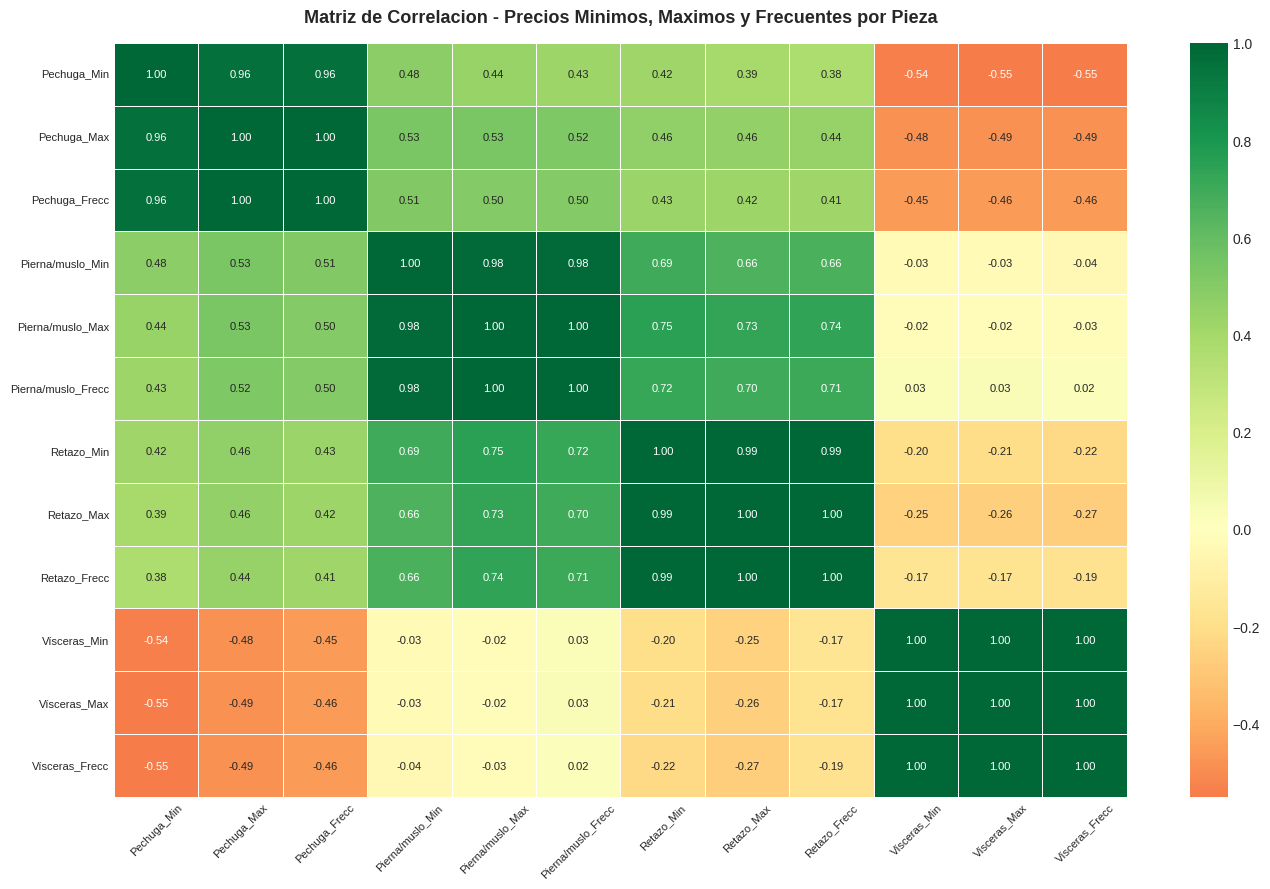

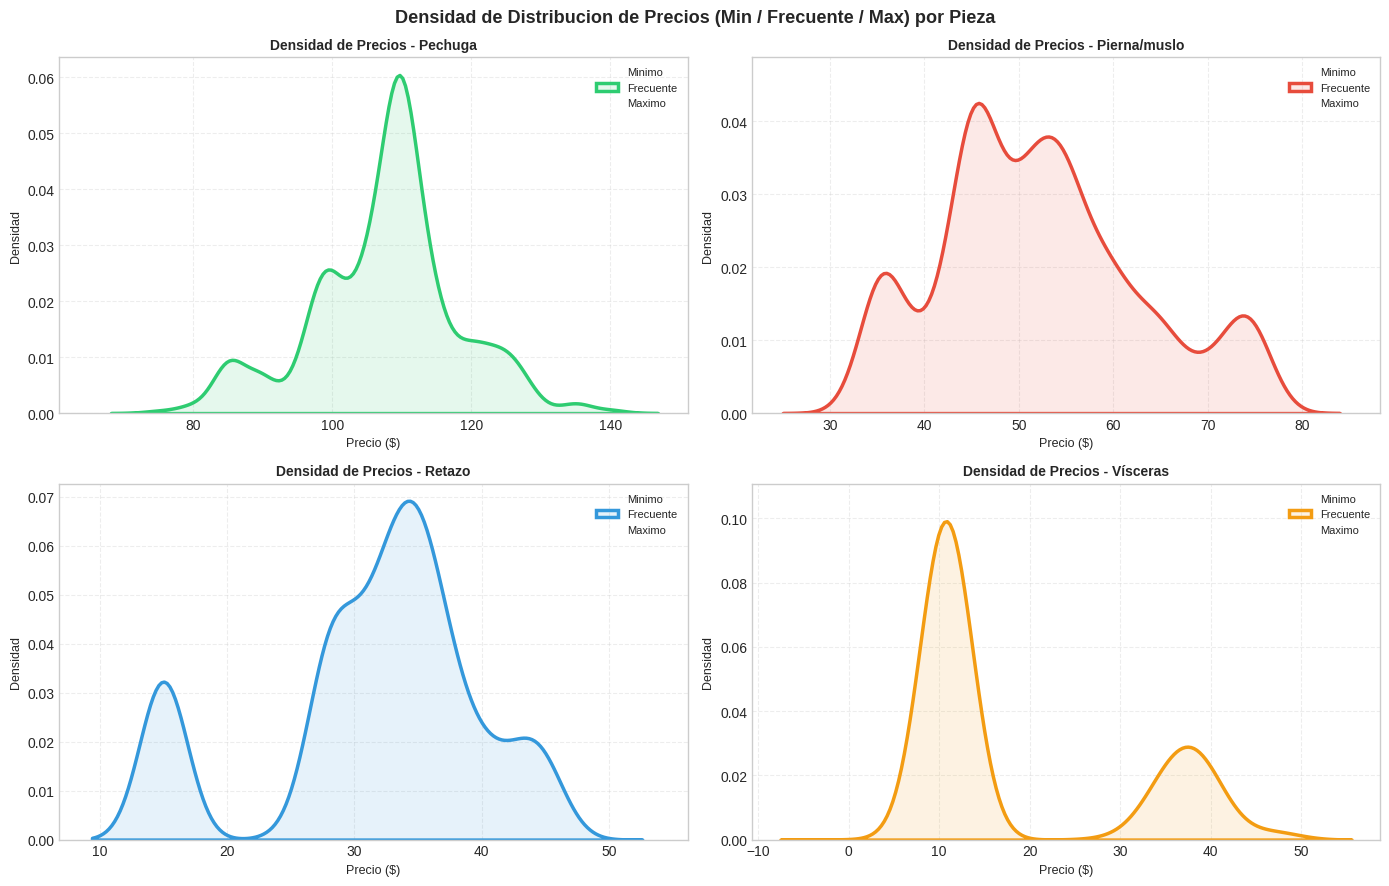


  TOP CORRELACIONES ENTRE COLUMNAS DE PRECIO (|r| > 0.75)
  Pechuga_Max  <->  Pechuga_Min  ->  r = 0.9604  (positiva fuerte)
  Pechuga_Frecc  <->  Pechuga_Min  ->  r = 0.9606  (positiva fuerte)
  Pechuga_Frecc  <->  Pechuga_Max  ->  r = 0.9966  (positiva fuerte)
  Pierna/muslo_Max  <->  Pierna/muslo_Min  ->  r = 0.9819  (positiva fuerte)
  Pierna/muslo_Frecc  <->  Pierna/muslo_Min  ->  r = 0.9825  (positiva fuerte)
  Pierna/muslo_Frecc  <->  Pierna/muslo_Max  ->  r = 0.9977  (positiva fuerte)
  Retazo_Max  <->  Retazo_Min  ->  r = 0.9949  (positiva fuerte)
  Retazo_Frecc  <->  Retazo_Min  ->  r = 0.9939  (positiva fuerte)
  Retazo_Frecc  <->  Retazo_Max  ->  r = 0.9974  (positiva fuerte)
  Vísceras_Max  <->  Vísceras_Min  ->  r = 0.9974  (positiva fuerte)
  Vísceras_Frecc  <->  Vísceras_Min  ->  r = 0.9970  (positiva fuerte)
  Vísceras_Frecc  <->  Vísceras_Max  ->  r = 0.9995  (positiva fuerte)


In [17]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

# --- Carga y preparación del DataFrame limpio ---
response_exp = requests.get(url_excel)
df_exp_pd    = cargar_datos_limpios(BytesIO(response_exp.content))
df_exp_pd['Fecha'] = pd.to_datetime(df_exp_pd['Fecha'], errors='coerce')
df_exp_pd    = df_exp_pd.dropna(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

piezas_exp  = ['Pechuga', 'Pierna/muslo', 'Retazo', 'Vísceras']
cols_precio = []
for pieza in piezas_exp:
    for sufijo in ['_Min', '_Max', '_Frecc']:
        col = f"{pieza}{sufijo}"
        if col in df_exp_pd.columns:
            df_exp_pd[col] = df_exp_pd[col].apply(limpiar_dinero)
            cols_precio.append(col)

df_exp_pd['Fecha_str'] = df_exp_pd['Fecha'].dt.strftime('%Y-%m-%d')
cols_spark = ['Fecha_str'] + [c for c in cols_precio if c in df_exp_pd.columns]

df_spark_exp = spark.createDataFrame(df_exp_pd[cols_spark].dropna(how='all'))
df_spark_exp = df_spark_exp.withColumnRenamed('Fecha_str', 'Fecha')

for col_name in [c for c in df_spark_exp.columns if c != 'Fecha']:
    df_spark_exp = df_spark_exp.withColumn(col_name, df_spark_exp[col_name].cast(DoubleType()))

print("=" * 70)
print("  SCHEMA DEL DATAFRAME DISTRIBUIDO (PySpark)")
print("=" * 70)
df_spark_exp.printSchema()

print("\n" + "=" * 70)
print("  MUESTRA DE LOS PRIMEROS 5 REGISTROS")
print("=" * 70)
df_spark_exp.show(5, truncate=False)

print("\n" + "=" * 70)
print("  ESTADÍSTICAS DESCRIPTIVAS COMPLETAS (describe)")
print("=" * 70)
df_spark_exp.describe().show(truncate=False)

# --- Resumen por pieza vía PySpark ---
print("\n" + "=" * 70)
print("  RESUMEN DE PRECIOS POR PIEZA AVÍCOLA")
print("=" * 70)

resumen_spark = {}
for pieza in piezas_exp:
    col_min  = f"{pieza}_Min"
    col_max  = f"{pieza}_Max"
    col_frec = f"{pieza}_Frecc"

    agg_exprs = []
    if col_min  in df_spark_exp.columns:
        agg_exprs += [F.min(col_min).alias('precio_min'), F.avg(col_min).alias('avg_min')]
    if col_max  in df_spark_exp.columns:
        agg_exprs += [F.max(col_max).alias('precio_max'), F.avg(col_max).alias('avg_max')]
    if col_frec in df_spark_exp.columns:
        agg_exprs += [F.avg(col_frec).alias('precio_frec_avg'),
                      F.stddev(col_frec).alias('precio_frec_std'),
                      F.expr(f"percentile_approx(`{col_frec}`, 0.5)").alias('mediana')]
    if not agg_exprs:
        continue

    stats = df_spark_exp.agg(*agg_exprs).collect()[0].asDict()
    resumen_spark[pieza] = {k: round(v, 2) if v is not None else None for k, v in stats.items()}

    print(f"\n  PIEZA: {pieza.upper()}")
    r = resumen_spark[pieza]
    if r.get('precio_min')      is not None: print(f"    Precio minimo registrado      : ${r['precio_min']:.2f}")
    if r.get('precio_max')      is not None: print(f"    Precio maximo registrado      : ${r['precio_max']:.2f}")
    if r.get('precio_frec_avg') is not None: print(f"    Precio frecuente (promedio)   : ${r['precio_frec_avg']:.2f}")
    if r.get('mediana')         is not None: print(f"    Mediana de precio frecuente   : ${r['mediana']:.2f}")
    if r.get('precio_frec_std') is not None: print(f"    Desviacion estandar           : ${r['precio_frec_std']:.2f}")

fecha_min_sp = df_spark_exp.agg(F.min('Fecha')).collect()[0][0]
fecha_max_sp = df_spark_exp.agg(F.max('Fecha')).collect()[0][0]
print(f"\n  Rango temporal del dataset : {fecha_min_sp}  ->  {fecha_max_sp}")
print(f"  Total de registros (filas) : {df_spark_exp.count():,}")
print(f"  Total de columnas          : {len(df_spark_exp.columns)}")

# --- Lugares de proveniencia ---
print("\n" + "=" * 70)
print("  LUGARES DE PROVENIENCIA (CENTROS DE DISTRIBUCION REGISTRADOS)")
print("=" * 70)
df_ubi_pd = pd.DataFrame(ubicaciones)[['nombre', 'lat', 'lon']]
df_ubi_pd.columns = ['Establecimiento_Granja', 'Latitud', 'Longitud']
spark.createDataFrame(df_ubi_pd).show(truncate=False)

# ── VISUALIZACION 1: Boxplot + Evolucion mensual ──────────────────────────
colores_exp = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

fig_exp, axes_exp = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.35)

ax_box = axes_exp[0]
data_box, labels_box = [], []
for pieza in piezas_exp:
    col_frec = f"{pieza}_Frecc"
    if col_frec in df_exp_pd.columns:
        serie = df_exp_pd[col_frec].apply(limpiar_dinero).dropna()
        if len(serie) > 0:
            data_box.append(serie.values)
            labels_box.append(pieza)

bp = ax_box.boxplot(data_box, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp['boxes'], colores_exp[:len(data_box)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for flier, color in zip(bp['fliers'], colores_exp[:len(data_box)]):
    flier.set(marker='o', color=color, alpha=0.4, markersize=4)

ax_box.set_xticklabels(labels_box, fontsize=10)
ax_box.set_title('Distribucion del Precio Frecuente por Pieza\n(Boxplot con notch de confianza 95%)',
                  fontsize=11, fontweight='bold')
ax_box.set_ylabel('Precio ($)', fontsize=10)
ax_box.grid(True, linestyle='--', alpha=0.4)

ax_evo = axes_exp[1]
df_exp_pd['Mes'] = df_exp_pd['Fecha'].dt.to_period('M').dt.to_timestamp()
for pieza, color in zip(piezas_exp, colores_exp):
    col_frec = f"{pieza}_Frecc"
    if col_frec not in df_exp_pd.columns:
        continue
    mes_avg = (df_exp_pd[['Mes', col_frec]].copy()
               .assign(Precio=lambda d: d[col_frec].apply(limpiar_dinero))
               .groupby('Mes')['Precio'].mean().reset_index())
    ax_evo.plot(mes_avg['Mes'], mes_avg['Precio'], lw=2, color=color, label=pieza, alpha=0.85)

ax_evo.set_title('Evolucion Mensual Promedio de Precios por Pieza', fontsize=11, fontweight='bold')
ax_evo.set_ylabel('Precio Promedio ($)', fontsize=10)
ax_evo.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_evo.tick_params(axis='x', rotation=35, labelsize=8)
ax_evo.legend(fontsize='small')
ax_evo.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Analisis Exploratorio del DataFrame Limpio - Precios Avicolas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── VISUALIZACION 2: Comparativa Min / Frecuente / Max ───────────────────
fig_rng, ax_rng = plt.subplots(figsize=(13, 5))
x_pos = np.arange(len(piezas_exp))
bar_w = 0.25

for k, (sufijo, label, color) in enumerate([
    ('_Min',   'Minimo',   '#27ae60'),
    ('_Frecc', 'Frecuente','#3498db'),
    ('_Max',   'Maximo',   '#e74c3c')
]):
    vals = []
    for pieza in piezas_exp:
        col = f"{pieza}{sufijo}"
        vals.append(df_exp_pd[col].apply(limpiar_dinero).dropna().mean() if col in df_exp_pd.columns else 0)
    bars = ax_rng.bar(x_pos + k * bar_w, vals, bar_w, label=label, color=color, alpha=0.82, edgecolor='white')
    ax_rng.bar_label(bars, fmt='$%.2f', fontsize=8, padding=2)

ax_rng.set_xticks(x_pos + bar_w)
ax_rng.set_xticklabels(piezas_exp, fontsize=11)
ax_rng.set_ylabel('Precio Promedio ($)', fontsize=10)
ax_rng.set_title('Comparativa de Precio Minimo, Frecuente y Maximo por Pieza (Promedios Historicos)',
                  fontsize=12, fontweight='bold')
ax_rng.legend(fontsize=10)
ax_rng.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ── VISUALIZACION 3: Heatmap de correlacion ──────────────────────────────
cols_num = [c for c in df_exp_pd.columns
            if any(p in c for p in piezas_exp)
            and any(s in c for s in ['_Min', '_Max', '_Frecc'])]
df_num      = df_exp_pd[cols_num].apply(lambda c: c.apply(limpiar_dinero))
corr_matrix = df_num.corr()

fig_corr, ax_corr = plt.subplots(figsize=(14, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax_corr, annot_kws={'size': 8})
ax_corr.set_title('Matriz de Correlacion - Precios Minimos, Maximos y Frecuentes por Pieza',
                   fontsize=13, fontweight='bold', pad=15)
ax_corr.tick_params(axis='x', rotation=45, labelsize=8)
ax_corr.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# ── VISUALIZACION 4: Densidad KDE por pieza ──────────────────────────────
fig_kde, axes_kde = plt.subplots(2, 2, figsize=(14, 9))
axes_kde = axes_kde.flatten()
plt.subplots_adjust(hspace=0.45, wspace=0.3)

for idx, (pieza, color) in enumerate(zip(piezas_exp, colores_exp)):
    ax_k   = axes_kde[idx]
    c_min  = f"{pieza}_Min"
    c_frec = f"{pieza}_Frecc"
    c_max  = f"{pieza}_Max"
    for col, lbl, lw, ls in [
        (c_min,  'Minimo',    1.5, '--'),
        (c_frec, 'Frecuente', 2.5, '-'),
        (c_max,  'Maximo',    1.5, ':')
    ]:
        if col in df_exp_pd.columns:
            serie_k = df_exp_pd[col].apply(limpiar_dinero).dropna()
            if len(serie_k) > 5:
                sns.kdeplot(serie_k, ax=ax_k, color=color, lw=lw, linestyle=ls,
                            label=lbl, fill=(lbl == 'Frecuente'), alpha=0.12 if lbl == 'Frecuente' else 0)
    ax_k.set_title(f'Densidad de Precios - {pieza}', fontsize=10, fontweight='bold')
    ax_k.set_xlabel('Precio ($)', fontsize=9)
    ax_k.set_ylabel('Densidad', fontsize=9)
    ax_k.legend(fontsize='8')
    ax_k.grid(True, linestyle='--', alpha=0.35)

plt.suptitle('Densidad de Distribucion de Precios (Min / Frecuente / Max) por Pieza',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── REPORTE TEXTUAL ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  TOP CORRELACIONES ENTRE COLUMNAS DE PRECIO (|r| > 0.75)")
print("=" * 70)
for col_a in corr_matrix.columns:
    for col_b in corr_matrix.columns:
        if col_a >= col_b:
            continue
        r = corr_matrix.loc[col_a, col_b]
        if abs(r) > 0.75:
            tipo = "positiva fuerte" if r > 0 else "negativa fuerte"
            print(f"  {col_a}  <->  {col_b}  ->  r = {r:.4f}  ({tipo})")

## Métricas y procesos de validación

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.02969e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.38646e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


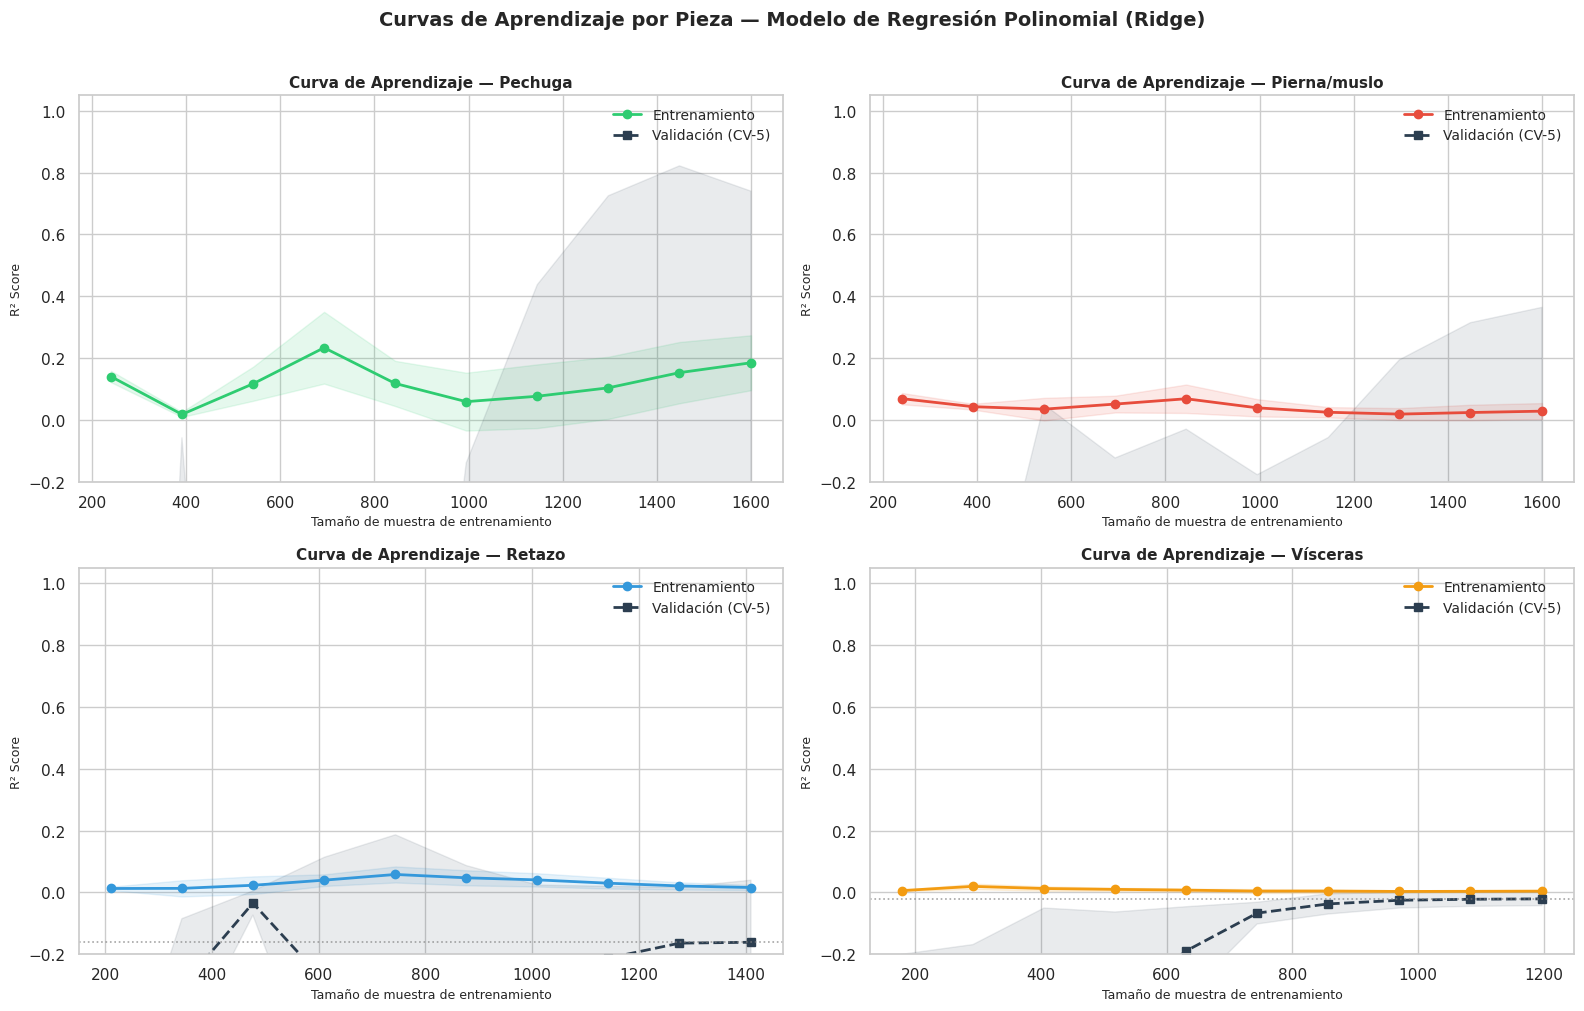

In [18]:
# ============================================================
# BLOQUE 1: CURVAS DE APRENDIZAJE POR PIEZA
# Muestra cómo mejora el R² a medida que el modelo ve más datos
# ============================================================

from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error

piezas_val   = ['Pechuga', 'Pierna/muslo', 'Retazo', 'Vísceras']
colores_val  = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

response_val = requests.get(url_excel)
df_val       = cargar_datos_limpios(BytesIO(response_val.content))
df_val['Fecha'] = pd.to_datetime(df_val['Fecha'], errors='coerce')
df_val = df_val.dropna(subset=['Fecha']).sort_values('Fecha')

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
plt.subplots_adjust(hspace=0.45, wspace=0.3)

resumen_metricas = {}

for idx, pieza in enumerate(piezas_val):
    ax           = axes[idx]
    freq_col     = f"{pieza}_Frecc"

    if freq_col not in df_val.columns:
        ax.set_title(f"{pieza}: sin datos")
        continue

    serie = df_val[['Fecha', freq_col]].copy()
    serie['Precio'] = serie[freq_col].apply(limpiar_dinero)
    serie = serie.dropna(subset=['Precio']).sort_values('Fecha')

    if len(serie) < 15:
        ax.set_title(f"{pieza}: muestra insuficiente")
        continue

    X_lc = serie['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y_lc = serie['Precio'].values

    poly_lc  = PolynomialFeatures(degree=2)
    X_lc_p   = poly_lc.fit_transform(X_lc)
    modelo_lc = Ridge(alpha=1.0)

    train_sizes, train_scores, val_scores = learning_curve(
        modelo_lc, X_lc_p, y_lc,
        cv=5, scoring='r2',
        train_sizes=np.linspace(0.15, 1.0, 10),
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores,  axis=1)
    val_mean   = np.mean(val_scores,   axis=1)
    val_std    = np.std(val_scores,    axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color=colores_val[idx], lw=2, label='Entrenamiento')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.12, color=colores_val[idx])

    ax.plot(train_sizes, val_mean, 's--', color='#2c3e50', lw=2, label='Validación (CV-5)')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.10, color='#2c3e50')

    ax.axhline(y=val_mean[-1], color='gray', linestyle=':', lw=1.2, alpha=0.7)
    ax.set_title(f"Curva de Aprendizaje — {pieza}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Tamaño de muestra de entrenamiento', fontsize=9)
    ax.set_ylabel('R² Score', fontsize=9)
    ax.set_ylim(-0.2, 1.05)
    ax.legend(fontsize='small')

    modelo_lc.fit(X_lc_p, y_lc)
    y_pred_lc = modelo_lc.predict(X_lc_p)
    r2   = r2_score(y_lc, y_pred_lc)
    mae  = mean_absolute_error(y_lc, y_pred_lc)
    rmse = np.sqrt(mean_squared_error(y_lc, y_pred_lc))
    resumen_metricas[pieza] = {'R2': r2, 'MAE': mae, 'RMSE': rmse,
                                'R2_val': val_mean[-1], 'n': len(serie)}

plt.suptitle('Curvas de Aprendizaje por Pieza — Modelo de Regresión Polinomial (Ridge)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.02969e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.38646e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


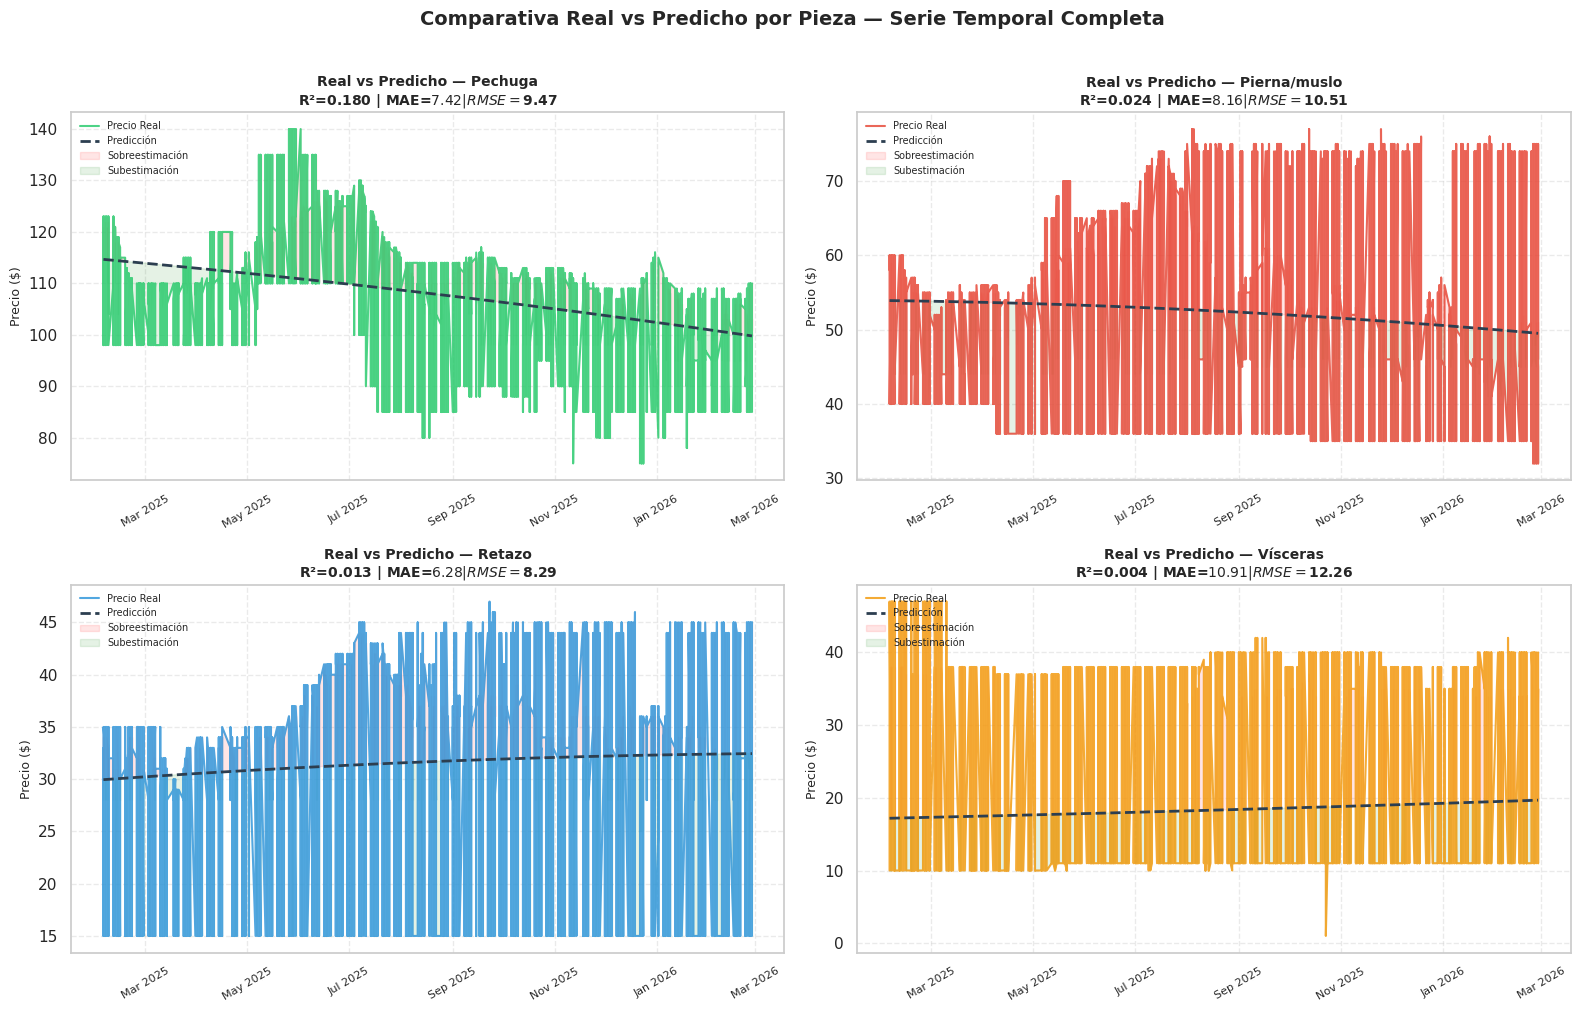

In [19]:
# COMPARATIVA REAL VS PREDICHO — SERIE TEMPORAL
# Superpone el precio histórico real contra la predicción
# del modelo para evaluar ajuste visual y desviación

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
axes2 = axes2.flatten()
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for idx, pieza in enumerate(piezas_val):
    ax           = axes2[idx]
    freq_col     = f"{pieza}_Frecc"

    if freq_col not in df_val.columns or pieza not in resumen_metricas:
        ax.set_title(f"{pieza}: sin datos")
        continue

    serie = df_val[['Fecha', freq_col]].copy()
    serie['Precio'] = serie[freq_col].apply(limpiar_dinero)
    serie = serie.dropna(subset=['Precio']).sort_values('Fecha').reset_index(drop=True)

    X_rv  = serie['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y_rv  = serie['Precio'].values
    poly_rv   = PolynomialFeatures(degree=2)
    X_rv_p    = poly_rv.fit_transform(X_rv)
    modelo_rv = Ridge(alpha=1.0)
    modelo_rv.fit(X_rv_p, y_rv)
    y_pred_rv = modelo_rv.predict(X_rv_p)

    residuos = y_rv - y_pred_rv

    ax.plot(serie['Fecha'], y_rv,      color=colores_val[idx], lw=1.5, alpha=0.85, label='Precio Real')
    ax.plot(serie['Fecha'], y_pred_rv, color='#2c3e50',        lw=2,   linestyle='--', label='Predicción')
    ax.fill_between(serie['Fecha'], y_rv, y_pred_rv,
                    where=(residuos > 0), alpha=0.10, color='red',   label='Sobreestimación')
    ax.fill_between(serie['Fecha'], y_rv, y_pred_rv,
                    where=(residuos < 0), alpha=0.10, color='green', label='Subestimación')

    r2   = resumen_metricas[pieza]['R2']
    mae  = resumen_metricas[pieza]['MAE']
    rmse = resumen_metricas[pieza]['RMSE']

    ax.set_title(f"Real vs Predicho — {pieza}\nR²={r2:.3f} | MAE=${mae:.2f} | RMSE=${rmse:.2f}",
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('Precio ($)', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize='7', loc='upper left')

plt.suptitle('Comparativa Real vs Predicho por Pieza — Serie Temporal Completa',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.02969e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.38646e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


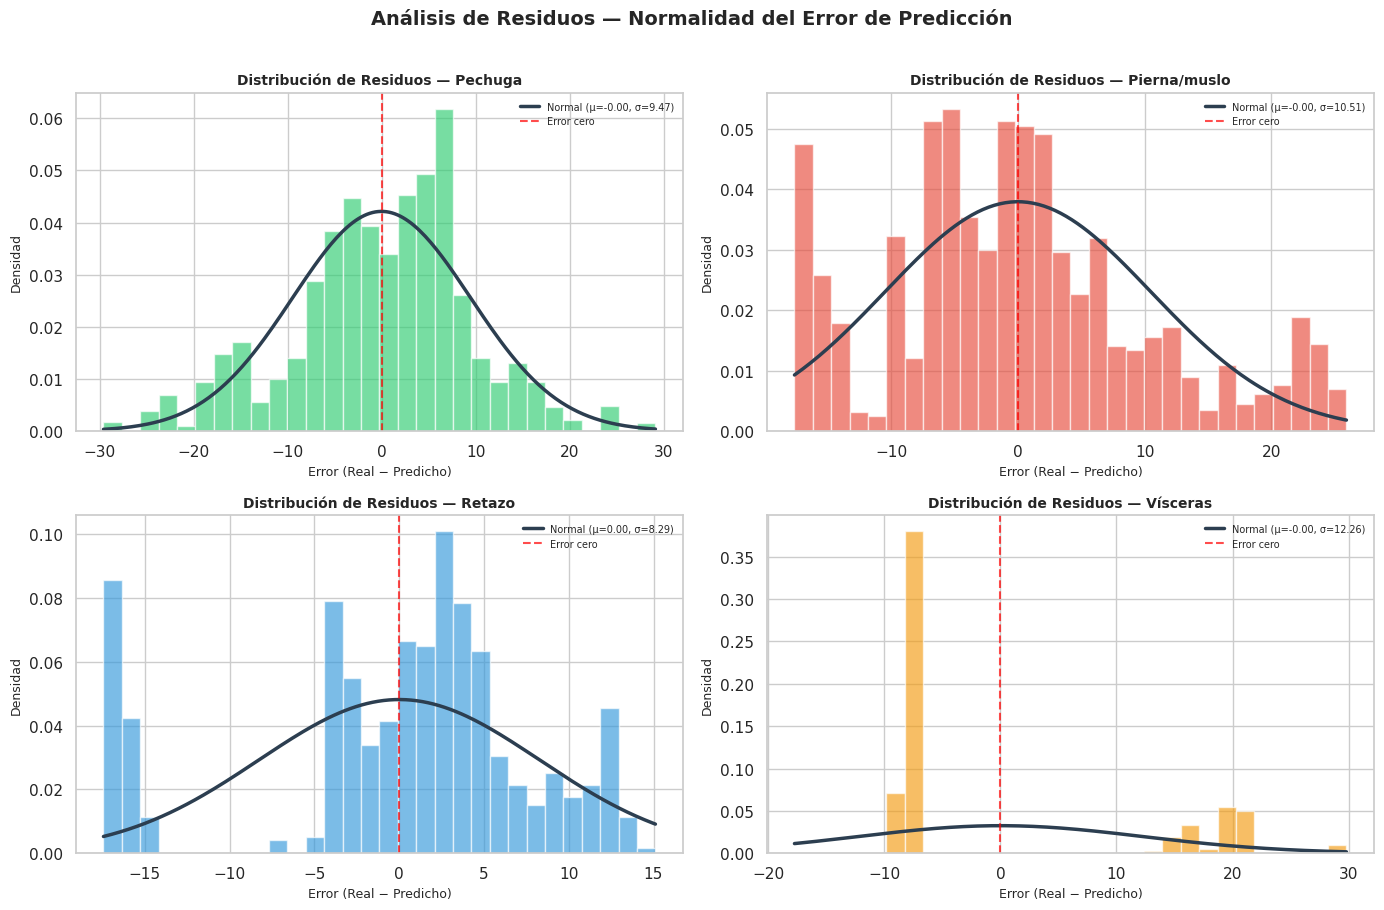

In [20]:
# DISTRIBUCIÓN DE RESIDUOS
# Evalúa si los errores del modelo siguen una distribución
# normal (criterio de buen ajuste estadístico)

fig3, axes3 = plt.subplots(2, 2, figsize=(14, 9))
axes3 = axes3.flatten()
plt.subplots_adjust(hspace=0.5, wspace=0.3)

from scipy.stats import probplot

for idx, pieza in enumerate(piezas_val):
    ax       = axes3[idx]
    freq_col = f"{pieza}_Frecc"

    if freq_col not in df_val.columns or pieza not in resumen_metricas:
        ax.set_title(f"{pieza}: sin datos")
        continue

    serie = df_val[['Fecha', freq_col]].copy()
    serie['Precio'] = serie[freq_col].apply(limpiar_dinero)
    serie = serie.dropna(subset=['Precio']).sort_values('Fecha')

    X_r   = serie['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y_r   = serie['Precio'].values
    poly_r   = PolynomialFeatures(degree=2)
    modelo_r = Ridge(alpha=1.0)
    modelo_r.fit(poly_r.fit_transform(X_r), y_r)
    residuos = y_r - modelo_r.predict(poly_r.transform(X_r))

    ax.hist(residuos, bins=30, color=colores_val[idx], alpha=0.65, edgecolor='white', density=True)

    mu_r, sigma_r = residuos.mean(), residuos.std()
    x_norm = np.linspace(residuos.min(), residuos.max(), 200)
    ax.plot(x_norm, norm.pdf(x_norm, mu_r, sigma_r),
            color='#2c3e50', lw=2.5, linestyle='-', label=f'Normal (μ={mu_r:.2f}, σ={sigma_r:.2f})')

    ax.axvline(0, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Error cero')
    ax.set_title(f"Distribución de Residuos — {pieza}", fontsize=10, fontweight='bold')
    ax.set_xlabel('Error (Real − Predicho)', fontsize=9)
    ax.set_ylabel('Densidad', fontsize=9)
    ax.legend(fontsize='7')

plt.suptitle('Análisis de Residuos — Normalidad del Error de Predicción',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

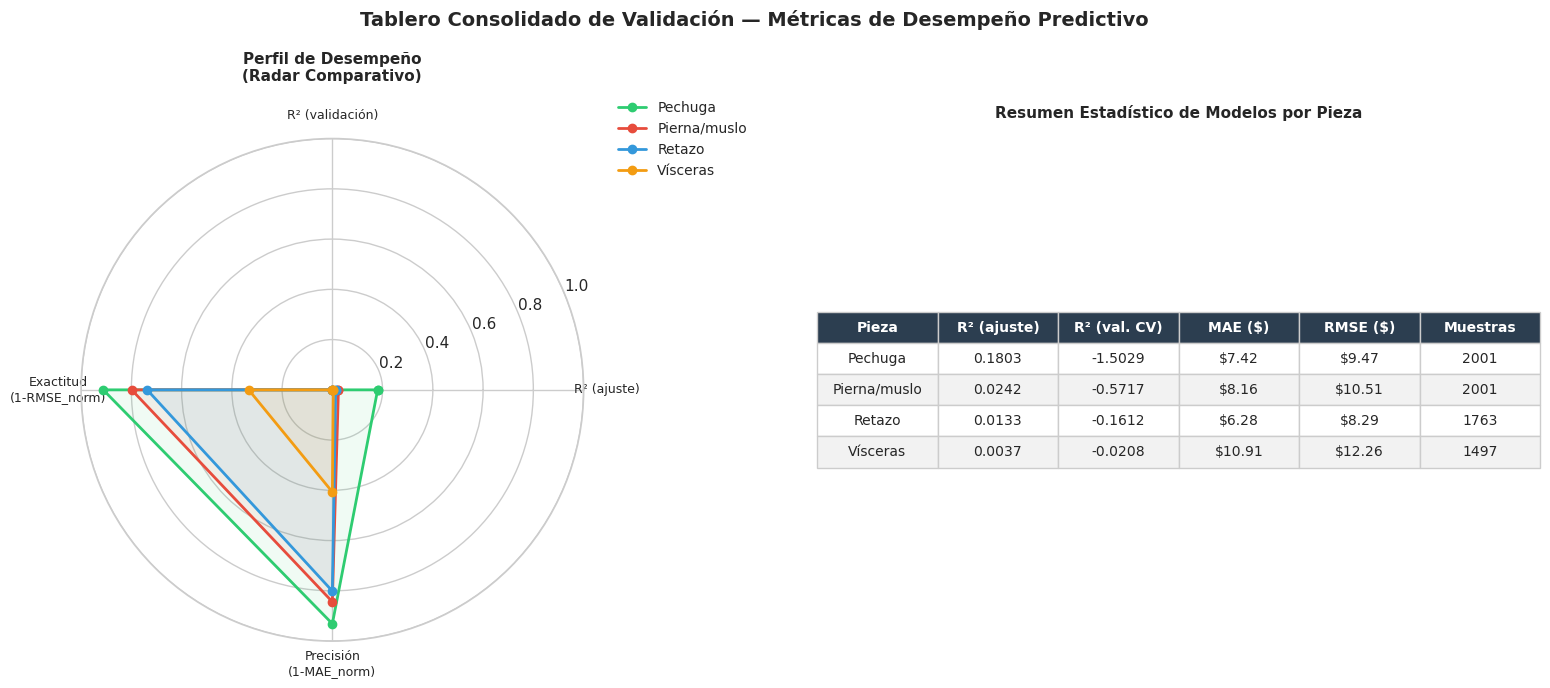

In [21]:
# TABLERO CONSOLIDADO DE MÉTRICAS
# Radar chart + tabla resumen con R², MAE, RMSE y R² validación
# para comparar el desempeño entre todas las piezas

fig4 = plt.figure(figsize=(16, 7))

# --- Sub-figura izquierda: Gráfico radar ---
ax_radar = fig4.add_subplot(121, polar=True)

categorias  = ['R² (ajuste)', 'R² (validación)', 'Exactitud\n(1-RMSE_norm)', 'Precisión\n(1-MAE_norm)']
n_cat       = len(categorias)
angulos     = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
angulos    += angulos[:1]

for idx, pieza in enumerate(piezas_val):
    if pieza not in resumen_metricas:
        continue
    m      = resumen_metricas[pieza]
    rango  = m['R2'] if m['R2'] > 0 else 0
    precio_medio = df_val[f"{pieza}_Frecc"].apply(limpiar_dinero).dropna().mean()

    rmse_norm = max(0, 1 - m['RMSE'] / precio_medio) if precio_medio > 0 else 0
    mae_norm  = max(0, 1 - m['MAE']  / precio_medio) if precio_medio > 0 else 0

    valores  = [max(0, m['R2']), max(0, m['R2_val']), rmse_norm, mae_norm]
    valores += valores[:1]

    ax_radar.plot(angulos, valores, 'o-', lw=2, color=colores_val[idx], label=pieza)
    ax_radar.fill(angulos, valores, alpha=0.07, color=colores_val[idx])

ax_radar.set_xticks(angulos[:-1])
ax_radar.set_xticklabels(categorias, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Perfil de Desempeño\n(Radar Comparativo)', fontsize=11, fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize='small')

# --- Sub-figura derecha: Tabla resumen ---
ax_tabla = fig4.add_subplot(122)
ax_tabla.axis('off')

encabezados = ['Pieza', 'R² (ajuste)', 'R² (val. CV)', 'MAE ($)', 'RMSE ($)', 'Muestras']
filas       = []
for pieza in piezas_val:
    if pieza in resumen_metricas:
        m = resumen_metricas[pieza]
        filas.append([
            pieza,
            f"{m['R2']:.4f}",
            f"{m['R2_val']:.4f}",
            f"${m['MAE']:.2f}",
            f"${m['RMSE']:.2f}",
            str(m['n'])
        ])

tabla = ax_tabla.table(
    cellText=filas,
    colLabels=encabezados,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 2.0)

for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('#ffffff')
    cell.set_edgecolor('#cccccc')

ax_tabla.set_title('Resumen Estadístico de Modelos por Pieza', fontsize=11, fontweight='bold', pad=15)

plt.suptitle('Tablero Consolidado de Validación — Métricas de Desempeño Predictivo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.82505e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.02969e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=2.38646e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


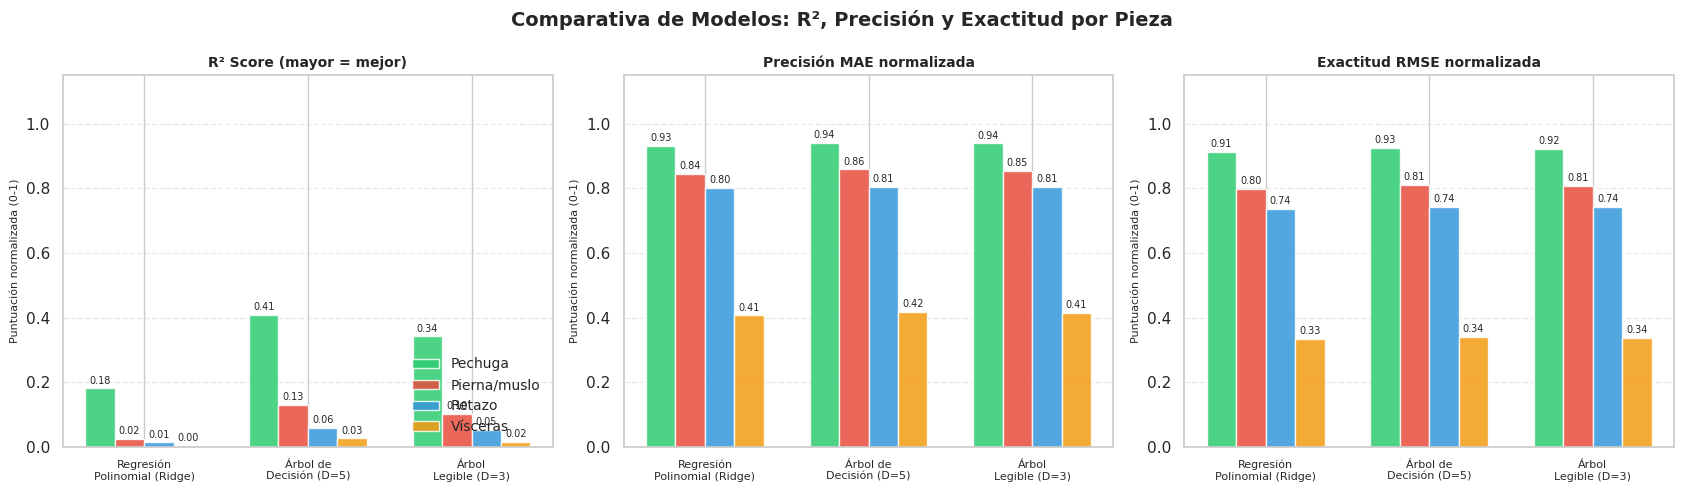

In [22]:
# COMPARATIVA DE MODELOS — BARRAS AGRUPADAS
# R², MAE normalizado y RMSE normalizado para Polinomial,
# Árbol de Decisión y Árbol Legible (por pieza objetivo)

fig5, axes5 = plt.subplots(1, 3, figsize=(17, 5))
plt.subplots_adjust(wspace=0.35)

nombres_modelos = ['Regresión\nPolinomial (Ridge)', 'Árbol de\nDecisión (D=5)', 'Árbol\nLegible (D=3)']
metricas_comp   = {pieza: {'R2': [], 'MAE_n': [], 'RMSE_n': []} for pieza in piezas_val}

for pieza in piezas_val:
    freq_col = f"{pieza}_Frecc"
    if freq_col not in df_val.columns:
        continue

    serie = df_val[['Fecha', freq_col]].copy()
    serie['Precio'] = serie[freq_col].apply(limpiar_dinero)
    serie = serie.dropna(subset=['Precio']).sort_values('Fecha')
    if len(serie) < 10:
        continue

    X_c   = serie['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
    y_c   = serie['Precio'].values
    p_med = y_c.mean()

    # Modelo 1: Regresión Polinomial Ridge
    poly_c  = PolynomialFeatures(degree=2)
    X_c_p   = poly_c.fit_transform(X_c)
    m1      = Ridge(alpha=1.0).fit(X_c_p, y_c)
    yp1     = m1.predict(X_c_p)

    # Modelo 2: Árbol de Decisión profundidad 5
    m2  = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_c, y_c)
    yp2 = m2.predict(X_c)

    # Modelo 3: Árbol Legible profundidad 3
    serie['Año'] = serie['Fecha'].dt.year
    serie['Mes'] = serie['Fecha'].dt.month
    X_c3 = serie[['Año', 'Mes']].values
    m3   = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_c3, y_c)
    yp3  = m3.predict(X_c3)

    yp_list = [yp1, yp2, yp3]
    metricas_comp[pieza] = {
        'R2':    [max(0, r2_score(y_c, yp))                                   for yp in yp_list],
        'MAE_n': [max(0, 1 - mean_absolute_error(y_c, yp) / p_med)            for yp in yp_list],
        'RMSE_n':[max(0, 1 - np.sqrt(mean_squared_error(y_c, yp)) / p_med)   for yp in yp_list],
    }

titulos_ejes  = ['R² Score (mayor = mejor)', 'Precisión MAE normalizada', 'Exactitud RMSE normalizada']
claves_ejes   = ['R2', 'MAE_n', 'RMSE_n']

for ax_idx, (ax5, clave, titulo) in enumerate(zip(axes5, claves_ejes, titulos_ejes)):
    x5    = np.arange(len(nombres_modelos))
    width = 0.18
    for p_idx, (pieza, color) in enumerate(zip(piezas_val, colores_val)):
        if not metricas_comp[pieza][clave]:
            continue
        offset = (p_idx - 1.5) * width
        bars = ax5.bar(x5 + offset, metricas_comp[pieza][clave], width,
                       label=pieza, color=color, alpha=0.85, edgecolor='white')
        ax5.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

    ax5.set_title(titulo, fontsize=10, fontweight='bold')
    ax5.set_xticks(x5)
    ax5.set_xticklabels(nombres_modelos, fontsize=8)
    ax5.set_ylim(0, 1.15)
    ax5.set_ylabel('Puntuación normalizada (0-1)', fontsize=8)
    ax5.grid(True, axis='y', linestyle='--', alpha=0.4)
    if ax_idx == 0:
        ax5.legend(fontsize='small', loc='lower right')

plt.suptitle('Comparativa de Modelos: R², Precisión y Exactitud por Pieza',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# REPORTE FINAL AUTOMÁTICO

print("\n" + "="*85)
print("  REPORTE DE VALIDACIÓN ESTADÍSTICA — MODELOS DEL MERCADO AVÍCOLA")
print("="*85)

for pieza in piezas_val:
    if pieza not in resumen_metricas:
        continue
    m = resumen_metricas[pieza]
    ajuste   = "EXCELENTE" if m['R2'] >= 0.85 else ("BUENO" if m['R2'] >= 0.70 else "MODERADO")
    gap_cv   = abs(m['R2'] - m['R2_val'])
    sobreaj  = "SÍ — revisar regularización" if gap_cv > 0.15 else "No detectado"
    print(f"\n  PIEZA: {pieza.upper()}")
    print(f"  R² ajuste   : {m['R2']:.4f}  → Calidad de ajuste: {ajuste}")
    print(f"  R² validación (CV-5): {m['R2_val']:.4f}  | Gap: {gap_cv:.4f}  | Sobreajuste: {sobreaj}")
    print(f"  MAE  : ${m['MAE']:.2f}  (error promedio absoluto por observación)")
    print(f"  RMSE : ${m['RMSE']:.2f}  (sensible a errores grandes)")
    print(f"  Muestras disponibles: {m['n']}")

print("\n" + "="*85)


  REPORTE DE VALIDACIÓN ESTADÍSTICA — MODELOS DEL MERCADO AVÍCOLA

  PIEZA: PECHUGA
  R² ajuste   : 0.1803  → Calidad de ajuste: MODERADO
  R² validación (CV-5): -1.5029  | Gap: 1.6832  | Sobreajuste: SÍ — revisar regularización
  MAE  : $7.42  (error promedio absoluto por observación)
  RMSE : $9.47  (sensible a errores grandes)
  Muestras disponibles: 2001

  PIEZA: PIERNA/MUSLO
  R² ajuste   : 0.0242  → Calidad de ajuste: MODERADO
  R² validación (CV-5): -0.5717  | Gap: 0.5958  | Sobreajuste: SÍ — revisar regularización
  MAE  : $8.16  (error promedio absoluto por observación)
  RMSE : $10.51  (sensible a errores grandes)
  Muestras disponibles: 2001

  PIEZA: RETAZO
  R² ajuste   : 0.0133  → Calidad de ajuste: MODERADO
  R² validación (CV-5): -0.1612  | Gap: 0.1745  | Sobreajuste: SÍ — revisar regularización
  MAE  : $6.28  (error promedio absoluto por observación)
  RMSE : $8.29  (sensible a errores grandes)
  Muestras disponibles: 1763

  PIEZA: VÍSCERAS
  R² ajuste   : 0.0037  

## Mini Dashboard Interactivo — IO · Marketing · Predicción de Precios

In [24]:
from pyspark.sql import functions as F

def cargar_df_dashboard():
    resp = requests.get(url_excel)
    df_d = cargar_datos_limpios(BytesIO(resp.content))
    df_d['Fecha'] = pd.to_datetime(df_d['Fecha'], errors='coerce')
    return df_d.dropna(subset=['Fecha']).sort_values('Fecha').reset_index(drop=True)

def limpiar_v(v):
    try:
        return float(str(v).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

df_dash     = cargar_df_dashboard()
piezas_dash = ['Pechuga', 'Pierna/muslo', 'Retazo', 'Visceras']

# ── Widgets ───────────────────────────────────────────────────────────────
titulo_ui = widgets.HTML(
    value=(
        "<div style='background:linear-gradient(135deg,#2c3e50,#3498db);"
        "padding:14px 20px;border-radius:8px;margin-bottom:10px'>"
        "<h3 style='color:white;margin:0'>Dashboard de Mercado Avicola</h3>"
        "<p style='color:#ecf0f1;font-size:12px;margin:4px 0 0'>"
        "Selecciona la pieza, ingresa el precio actual y el volumen de mercado</p>"
        "</div>"
    )
)
dd_pieza = widgets.Dropdown(
    options=piezas_dash, value='Pechuga', description='Pieza:',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='210px')
)
ft_precio = widgets.FloatText(
    value=0.0, description='Precio actual ($):',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='210px')
)
dd_volumen = widgets.Dropdown(
    options=['Bajo (< 500k)', 'Medio (500k - 1M)', 'Alto (> 1M)'],
    description='Volumen:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='230px')
)
dd_horizonte = widgets.Dropdown(
    options=['7 dias', '15 dias', '30 dias', '60 dias'], value='30 dias',
    description='Horizonte:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='190px')
)
btn_run  = widgets.Button(
    description='Analizar', button_style='success',
    layout=widgets.Layout(width='150px', height='36px')
)
out_dash = widgets.Output()

panel = widgets.VBox([
    titulo_ui,
    widgets.HBox([dd_pieza, ft_precio, dd_volumen, dd_horizonte],
                 layout=widgets.Layout(gap='12px', flex_flow='row wrap')),
    widgets.HBox([btn_run], layout=widgets.Layout(margin='8px 0')),
    out_dash
])

# ── Logica central ────────────────────────────────────────────────────────
def generar_dashboard(b):
    with out_dash:
        clear_output(wait=True)

        pieza        = dd_pieza.value
        precio_ingr  = ft_precio.value
        vol_sel      = dd_volumen.value
        horizonte    = int(dd_horizonte.value.split()[0])
        freq_col     = f"{pieza}_Frecc"
        min_col      = f"{pieza}_Min"
        max_col      = f"{pieza}_Max"

        # Buscar columna Frecc con variaciones de nombre (Visceras vs Visceras con tilde)
        col_real = next((c for c in df_dash.columns if pieza.split('/')[0].lower() in c.lower() and 'Fre' in c), None)
        if col_real:
            freq_col = col_real

        if freq_col not in df_dash.columns:
            print(f"No se encontraron datos para '{pieza}'.")
            return

        # --- Serie limpia ---
        cols_serie = ['Fecha', freq_col] + [c for c in [min_col, max_col] if c in df_dash.columns]
        serie = df_dash[cols_serie].copy()
        serie['Precio'] = serie[freq_col].apply(limpiar_v)
        if min_col in serie.columns: serie['Min'] = serie[min_col].apply(limpiar_v)
        if max_col in serie.columns: serie['Max'] = serie[max_col].apply(limpiar_v)
        serie = serie.dropna(subset=['Precio']).sort_values('Fecha').reset_index(drop=True)

        if len(serie) < 10:
            print("Datos insuficientes para esta pieza.")
            return

        # --- KPIs con PySpark ---
        df_sp = spark.createDataFrame(
            df_dash[['Fecha', freq_col]]
            .assign(Fecha=df_dash['Fecha'].dt.strftime('%Y-%m-%d'),
                    **{freq_col: df_dash[freq_col].apply(limpiar_v)})
            .dropna()
        )
        stats_sp = df_sp.agg(
            F.min(freq_col).alias('p_min'),
            F.max(freq_col).alias('p_max'),
            F.avg(freq_col).alias('p_avg'),
            F.stddev(freq_col).alias('p_std'),
            F.expr(f"percentile_approx(`{freq_col}`, 0.25)").alias('q1'),
            F.expr(f"percentile_approx(`{freq_col}`, 0.75)").alias('q3'),
            F.count(freq_col).alias('n_registros')
        ).collect()[0].asDict()

        p_min = float(stats_sp.get('p_min') or 0)
        p_max = float(stats_sp.get('p_max') or 0)
        p_avg = float(stats_sp.get('p_avg') or 0)
        p_std = float(stats_sp.get('p_std') or 0)
        q1    = float(stats_sp.get('q1')    or 0)
        q3    = float(stats_sp.get('q3')    or 0)
        n_reg = int(stats_sp.get('n_registros') or 0)

        # --- Modelo Ridge Polinomial ---
        X_d    = serie['Fecha'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
        y_d    = serie['Precio'].values
        poly_d = PolynomialFeatures(degree=2)
        mdl_d  = Ridge(alpha=1.0).fit(poly_d.fit_transform(X_d), y_d)

        fecha_hoy  = pd.Timestamp.today()
        pred_hoy   = mdl_d.predict(poly_d.transform([[fecha_hoy.toordinal()]]))[0]
        fecha_fut  = fecha_hoy + timedelta(days=horizonte)
        pred_fut   = mdl_d.predict(poly_d.transform([[fecha_fut.toordinal()]]))[0]
        tendencia  = "ALZA" if pred_fut > pred_hoy else "BAJA"
        cambio_pct = ((pred_fut - pred_hoy) / pred_hoy * 100) if pred_hoy > 0 else 0

        # --- Recomendacion de marketing ---
        vol_map    = {'Bajo (< 500k)': 0.3, 'Medio (500k - 1M)': 0.6, 'Alto (> 1M)': 1.0}
        vol_factor = vol_map.get(vol_sel, 0.6)
        precio_ref = precio_ingr if precio_ingr > 0 else pred_hoy

        umbral_compra = pred_hoy * 0.97
        umbral_venta  = pred_hoy * 1.05

        if precio_ref <= umbral_compra and tendencia == "ALZA":
            decision   = "COMPRAR / ABASTECER"
            color_dec  = '#27ae60'
            icono      = "COMPRAR"
            razon      = (f"Precio ingresado (${precio_ref:.2f}) esta por debajo del umbral "
                          f"(${umbral_compra:.2f}) y la tendencia proyecta alza del {abs(cambio_pct):.1f}%.")
            estrategia = ("Compra anticipada antes del alza. Negociar volumen con proveedor y "
                          "almacenar si hay capacidad. Comunicar frescura y origen local al consumidor.")
        elif precio_ref >= umbral_venta:
            decision   = "VENDER / LIQUIDAR"
            color_dec  = '#e74c3c'
            icono      = "VENDER"
            razon      = (f"Precio (${precio_ref:.2f}) supera el umbral de venta (${umbral_venta:.2f}). "
                          f"Cambio proyectado a {horizonte}d: {cambio_pct:+.1f}%.")
            estrategia = ("Liquidar inventario existente. Activar promociones de volumen (paquetes 2 kg+). "
                          "Evitar nuevas compras hasta normalizacion. Considerar combos con otras piezas.")
        elif tendencia == "BAJA" and vol_factor > 0.5:
            decision   = "ESPERAR / MONITOREAR"
            color_dec  = '#f39c12'
            icono      = "ESPERAR"
            razon      = (f"Tendencia a la baja ({cambio_pct:+.1f}% en {horizonte}d) con alto volumen. "
                          f"Precio predicho: ${pred_fut:.2f}.")
            estrategia = ("Mantener stock minimo. Revisar precio en 7 dias. Usar precios psicologicos (.99) "
                          "para mantener demanda sin sacrificar margen. Vigilar la competencia.")
        else:
            decision   = "PRECIO DINAMICO"
            color_dec  = '#8e44ad'
            icono      = "DINAMICO"
            razon      = (f"Condiciones mixtas. Prediccion a {horizonte}d: ${pred_fut:.2f} "
                          f"({cambio_pct:+.1f}%). Desviacion estandar historica: ${p_std:.2f}.")
            estrategia = (f"Ajustar precio diario segun demanda observada. Descuentos cruzados con otras "
                          f"piezas para aumentar ticket promedio. IQR del mercado: ${q1:.2f} - ${q3:.2f}.")

        # ── Layout del dashboard ──────────────────────────────────────────
        fig_d = plt.figure(figsize=(18, 13))
        fig_d.patch.set_facecolor('#f0f3f7')
        gs = fig_d.add_gridspec(3, 3, hspace=0.55, wspace=0.38)

        # G1: Serie temporal + prediccion + banda
        ax1 = fig_d.add_subplot(gs[0, :2])
        ax1.set_facecolor('#fafafa')
        if 'Min' in serie.columns and 'Max' in serie.columns:
            ax1.fill_between(serie['Fecha'],
                             serie['Min'].ffill(), serie['Max'].ffill(),
                             alpha=0.10, color='#3498db', label='Banda Min-Max')
        ax1.plot(serie['Fecha'], serie['Precio'],
                 color='#2c3e50', lw=1.6, alpha=0.85, label='Precio Frecuente')
        fechas_pred = pd.date_range(serie['Fecha'].min(), fecha_fut, freq='W')
        X_pred = np.array([[f.toordinal()] for f in fechas_pred])
        y_pred = mdl_d.predict(poly_d.transform(X_pred))
        ax1.plot(fechas_pred, y_pred, '--', color='#e74c3c', lw=2.2, label='Tendencia predicha')
        ax1.axvline(fecha_hoy, color='#7f8c8d', lw=1.2, linestyle=':', alpha=0.8)
        ax1.scatter([fecha_fut], [pred_fut], s=90, color='#e74c3c', zorder=6,
                    edgecolors='white', linewidths=1.5,
                    label=f'Pred. {horizonte}d: ${pred_fut:.2f}')
        ax1.axhspan(q1, q3, alpha=0.07, color='#3498db', label=f'IQR (${q1:.2f}-${q3:.2f})')
        ax1.set_title(f'Comportamiento Historico y Prediccion - {pieza}', fontsize=11, fontweight='bold')
        ax1.set_ylabel('Precio ($)')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax1.tick_params(axis='x', rotation=30, labelsize=8)
        ax1.legend(fontsize='8', loc='upper left', framealpha=0.9)
        ax1.grid(True, linestyle='--', alpha=0.35)

        # G2: Tarjeta de decision
        ax2 = fig_d.add_subplot(gs[0, 2])
        ax2.set_facecolor(color_dec + '15')
        ax2.axis('off')
        ax2.text(0.5, 0.88, f"[ {icono} ]", ha='center', va='center',
                 fontsize=14, fontweight='bold', color=color_dec, transform=ax2.transAxes)
        ax2.text(0.5, 0.74, decision, ha='center', va='center',
                 fontsize=12, fontweight='bold', color=color_dec, transform=ax2.transAxes)
        y_text = 0.58
        for linea in razon.split('. '):
            if linea.strip():
                ax2.text(0.5, y_text, linea.strip() + '.', ha='center', va='center',
                         fontsize=7.8, color='#34495e', style='italic',
                         transform=ax2.transAxes, wrap=True)
                y_text -= 0.11
        ax2.text(0.5, 0.14, estrategia, ha='center', va='center',
                 fontsize=7.5, color='#2c3e50', transform=ax2.transAxes,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor=color_dec))
        ax2.set_title('Recomendacion de Marketing', fontsize=10, fontweight='bold', pad=8)

        # G3: Distribucion historica
        ax3 = fig_d.add_subplot(gs[1, 0])
        ax3.set_facecolor('#fafafa')
        ax3.hist(serie['Precio'], bins=28, color='#3498db', alpha=0.65,
                 edgecolor='white', density=True, label='Distribucion')
        mu_h, sg_h = serie['Precio'].mean(), serie['Precio'].std()
        x_n = np.linspace(serie['Precio'].min(), serie['Precio'].max(), 200)
        ax3.plot(x_n, norm.pdf(x_n, mu_h, sg_h), color='#e74c3c', lw=2.2, label='Curva normal')
        ax3.axvline(mu_h,      color='#2c3e50', linestyle='--', lw=1.8, label=f'Media ${mu_h:.2f}')
        ax3.axvline(precio_ref,color='#27ae60', linestyle='-',  lw=2.2, label=f'Precio ref ${precio_ref:.2f}')
        ax3.axvspan(q1, q3, alpha=0.08, color='#f39c12', label='IQR')
        ax3.set_title('Distribucion Historica del Precio', fontsize=10, fontweight='bold')
        ax3.set_xlabel('Precio ($)', fontsize=8)
        ax3.legend(fontsize='7')
        ax3.grid(True, linestyle='--', alpha=0.3)

        # G4: Promedio mensual 12 meses
        ax4 = fig_d.add_subplot(gs[1, 1])
        ax4.set_facecolor('#fafafa')
        corte12 = serie['Fecha'].max() - pd.DateOffset(months=12)
        mens = (serie[serie['Fecha'] >= corte12].copy()
                .assign(Mes=lambda d: d['Fecha'].dt.to_period('M').dt.to_timestamp())
                .groupby('Mes')['Precio'].mean().reset_index())
        colores_bar = ['#e74c3c' if v == mens['Precio'].max()
                       else '#27ae60' if v == mens['Precio'].min()
                       else '#3498db' for v in mens['Precio']]
        ax4.bar(range(len(mens)), mens['Precio'], color=colores_bar, alpha=0.82, edgecolor='white')
        ax4.set_xticks(range(len(mens)))
        ax4.set_xticklabels([m.strftime('%b\n%y') for m in mens['Mes']], fontsize=7)
        ax4.axhline(mens['Precio'].mean(), color='#2c3e50', linestyle='--', lw=1.5, label='Promedio anual')
        ax4.set_title('Precio Mensual Promedio (12 meses)', fontsize=10, fontweight='bold')
        ax4.set_ylabel('Precio ($)', fontsize=8)
        ax4.legend(fontsize='7')
        ax4.grid(True, axis='y', linestyle='--', alpha=0.3)

        # G5: Volatilidad movil 30 dias
        ax5 = fig_d.add_subplot(gs[1, 2])
        ax5.set_facecolor('#fafafa')
        vol30 = serie['Precio'].rolling(30, min_periods=5).std()
        ax5.fill_between(serie['Fecha'], vol30.fillna(0),
                         alpha=0.40, color='#f39c12', label='Volatilidad 30d')
        ax5.plot(serie['Fecha'], vol30, color='#e67e22', lw=1.5)
        ax5.axhline(vol30.mean(), color='#2c3e50', linestyle='--', lw=1.3,
                    label=f'Media ${vol30.mean():.2f}')
        ax5.set_title('Volatilidad Movil (30 dias)', fontsize=10, fontweight='bold')
        ax5.set_ylabel('Desv. Estandar ($)', fontsize=8)
        ax5.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax5.tick_params(axis='x', rotation=30, labelsize=7)
        ax5.legend(fontsize='7')
        ax5.grid(True, linestyle='--', alpha=0.3)

        # G6: KPIs calculados con PySpark
        ax6 = fig_d.add_subplot(gs[2, :])
        ax6.set_facecolor('#f0f3f7')
        ax6.axis('off')

        kpis = [
            ('Precio\nMinimo',     f'${p_min:.2f}',  '#27ae60'),
            ('Precio\nMaximo',     f'${p_max:.2f}',  '#e74c3c'),
            ('Precio\nPromedio',   f'${p_avg:.2f}',  '#3498db'),
            ('Desv.\nEstandar',    f'${p_std:.2f}',  '#8e44ad'),
            ('Q1',                 f'${q1:.2f}',     '#16a085'),
            ('Q3',                 f'${q3:.2f}',     '#d35400'),
            ('Pred.\nHoy',         f'${pred_hoy:.2f}','#e67e22'),
            (f'Pred.\n{horizonte}d',f'${pred_fut:.2f}','#c0392b'),
            ('Tendencia',          tendencia,         '#27ae60' if tendencia == "ALZA" else '#e74c3c'),
            ('Registros\n(Spark)', f'{n_reg:,}',     '#2c3e50'),
        ]
        n_kpi = len(kpis)
        for k, (label, valor, color) in enumerate(kpis):
            x_pos = (k + 0.5) / n_kpi
            ax6.add_patch(plt.Rectangle(
                (k / n_kpi + 0.004, 0.04), 1 / n_kpi - 0.008, 0.92,
                transform=ax6.transAxes,
                facecolor=color + '20', edgecolor=color + '60', linewidth=1, clip_on=False
            ))
            ax6.text(x_pos, 0.72, label, ha='center', va='center',
                     fontsize=8.5, color='#2c3e50', transform=ax6.transAxes)
            ax6.text(x_pos, 0.30, valor, ha='center', va='center',
                     fontsize=13, fontweight='bold', color=color, transform=ax6.transAxes)

        ax6.set_title(f'KPIs del Mercado - {pieza}  |  Calculados con PySpark',
                      fontsize=10, fontweight='bold', pad=10)

        fig_d.suptitle(
            f'Dashboard de Mercado Avicola - {pieza}  |  Volumen: {vol_sel}  |  Horizonte: {horizonte} dias',
            fontsize=14, fontweight='bold', color='#1a252f', y=1.01
        )
        plt.show()

btn_run.on_click(generar_dashboard)
display(panel)